## Preparation

### Libraries import & metadata storage definitions

In [ ]:
import os
import numpy as np
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import root_mean_squared_error

from matplotlib import pyplot as plt, colors, cm

In [2]:
checkpoint_dir = "checkpoints_cifar100"
graph_dir = "graphs_cifar100"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common key functions: plots & training

In [94]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                graph_dir: str = "graphs"):
    epochs_from1 = epochs + 1
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i for i in range(len(trains))],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i for i in range(len(tests))],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    
    xticks_step = (epochs_from1 // 50) if (epochs_from1 >= 100) else 5
    max_metric = max(trains + tests)
    yticks = [i for i in range(0, int(max_metric * 10 + 1) // 10, int(max_metric) // 5)]
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", 
        xlim=(-xticks_step, epochs_from1 + xticks_step), 
        xticks=[i for i in range(0, epochs_from1, xticks_step)] + [epochs_from1],
        ylabel=metric_name,
        yticks=yticks
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}.png"))
    

def centralize_colormap(values, 
                        center: float = 0):
    values_min = values.min()
    values_max = values.max()
    border = max(abs(values_min), abs(values_max))
    
    return colors.TwoSlopeNorm(
        vmin=-border,
        vcenter=center, 
        vmax=border
    )


def plot_heatmap(values,
                 figsize = None,
                 cmap_name: str = "seismic",
                 title: str = "Weights heatmap"):    
    plt.figure(figsize=figsize or (25, 3))
    plt.imshow(
        values, 
        origin="lower",
        cmap=cmap_name, 
        norm=centralize_colormap(values),
        extent=(0, len(values[0]) + 1, 0, len(values) + 1)
    )  
    plt.title(title)  
    plt.colorbar()  
    plt.show() 


def plot_colored_barplot(values,
                         values_color,
                         cmap_name: str = "seismic",
                         edge_color: str = "black",
                         title: str = "Values barplot",
                         x_label: str = "",
                         y_label: str = ""):
    fig, ax = plt.subplots(figsize=(25, 5))
    
    values_cmap = plt.get_cmap(cmap_name)
    norm = centralize_colormap(values_color)
    ax.bar(
        [i for i in range(len(values))],
        values, 
        color=values_cmap(norm(values_color)),
        edgecolor=edge_color
    )
    
    scalar_map = cm.ScalarMappable(
        cmap=values_cmap, 
        norm=norm
    )
    scalar_map.set_array([])
    colorbar = plt.colorbar(scalar_map, ax=ax)
    colorbar.set_label("Percentage of variance explained")
    
    ax.set(
        title=title,
        xlabel=x_label,
        ylabel=y_label
    )
    plt.grid(True, alpha=0.3, zorder=0)
    plt.show() 

In [4]:
def train_epoch(model: torch.nn.Module,
                train_loader: DataLoader,
                optimizer,
                criterion,
                device: torch.device = torch.device("cpu")):
    model.train()
    
    train_loss = 0.0
    correct = 0
    total = 0
        
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
            
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
            
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    train_acc = 100. * correct / total

    return train_loss, train_acc


def validate_epoch(model: torch.nn.Module,
                   test_loader: DataLoader,
                   criterion,
                   device: torch.device = torch.device("cpu")):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
                
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
    test_acc = 100. * correct / total

    return test_loss, test_acc


def train_n_epochs(model: torch.nn.Module,
                   train_loader: DataLoader, 
                   test_loader: DataLoader,
                   optimizer,
                   criterion,
                   scheduler,
                   model_name: str = "",
                   dataset_name: str = "dataset",
                   device: torch.device = torch.device("cpu"),
                   epochs: int = 150,
                   checkpoint_dir: str = "checkpoints",
                   with_plots: bool = True,
                   graph_dir: str = "",
                   verbose: bool = True):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model_name = model_name or model.__class__.__name__
    model.to(device)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []    
    best_acc = 0
    
    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}_last.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}_best.pth"))
        
        if verbose:
            epoch_time = time() - start_time
            print(
                f"Epoch: {epoch+1}/{epochs} | "
                f"Time: {epoch_time:.2f}s | "
                f"Train Loss: {train_loss/len(train_loader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss/len(test_loader):.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.6f}"
            )

        if with_plots:
            graph_dir = graph_dir or f"graphs_{model_name}_{epochs}epochs"
            os.makedirs(graph_dir, exist_ok=True)
            plot_metric(train_losses, test_losses, epoch, model_name=model_name, dataset_name=dataset_name, metric_name="Loss", graph_dir=graph_dir)
            plot_metric(train_accs, test_accs, epoch, model_name=model_name, dataset_name=dataset_name, metric_name="Accuracy", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")
    
    return train_losses, train_accs, test_losses, test_accs

## Dataset download & instantiation

### CIFAR-100 

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_X_3_2_GF и датасет [CIFAR-100](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR100.html). 

Датасет CIFAR-100 содержит 60 000 цветных изображений (50 000 в подсете train и 10 000 в подсете test) размерности 32х32 пикселя, каждое из которых соотносится ровно с 1 из 100 классов. Классы сбалансированы: каждый класс представлен 600 изображениями.

Модель для ускорения обучения инициализируется весами, предобученными на датасете [ImageNet](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview) со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992

с дальнейшей адаптацией архитектуры под CIFAR-100.

In [5]:
def make_train_loader_cifar100(data_dir: str, 
                               batch_size: int = 256, 
                               num_workers: int = 4):
    transforms_train = transforms.Compose([
        transforms.Resize(32),
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.5, 
            contrast=0.5, 
            hue=0.5
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

def make_val_loader_cifar100(data_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    transforms_val = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=False,
        download=True,
        transform=transforms_val
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

In [6]:
dataset_dir_cifar100 = "D:/cifar100"
dataset_name = "CIFAR100"
n_classes = 100
picture_size = 32

batch_size = 128
num_workers = 4

In [7]:
print(f"[ ] Creating dataloaders for dataset {dataset_name}...")
train_loader = make_train_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
val_loader = make_val_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
classes_names = train_loader.dataset.classes  # type: ignore
print(f"[V] Dataloaders for dataset {dataset_name} created")

[ ] Creating dataloaders for dataset CIFAR100...
[V] Dataloaders for dataset CIFAR100 created


## Model preparation

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### RegNetX_3_2 download & instantiation

In [9]:
def adapt_model_cifar100(model, 
                         n_classes: int,
                         in_channels: int = 3, 
                         out_channels: int = 32,
                         kernel_size: int = 3,
                         stride: int = 1, 
                         padding: int = 1,
                         bias: bool = False):
    model.stem[0] = torch.nn.Conv2d(
        in_channels = in_channels, out_channels = out_channels, 
        kernel_size=kernel_size, stride=stride, padding=padding, 
        bias=bias
    )
    model.fc = torch.nn.Linear(model.fc.in_features, n_classes)

In [59]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
# regnetx_16 = models.regnet_x_32gf(weights=models.RegNet_X_32GF_Weights.DEFAULT, progress=True)
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.to(device)
regnetx_3_2_name = "RegNetX_3_2"
print(f"[V] {regnetx_3_2_name} instantiated and adapted for CIFAR-100")

[ ] Instantiating model...
[V] RegNetX_3_2 instantiated and adapted for CIFAR-100


#### Use fine-tuned model from checkpoint

In [21]:
# checkpoint_path = os.path.join(checkpoint_dir, "basic_checkpoints/RegNetX_3_2_CIFAR100_57.34.pth")
checkpoint_path = os.path.join(checkpoint_dir, "finetuning_bin_input_RegNetX_3_2_CIFAR100_epochs_200_lr_0.0001/RegNetX_3_2_CIFAR100_best.pth")
print("[ ] Loading checkpoints from path:", checkpoint_path, "...")
checkpoint = torch.load(checkpoint_path)
print("[V] Checkpoints loaded")

print("[ ] Loading fine-tuned model for CIFAR-100...")
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

[ ] Loading checkpoints from path: checkpoints_cifar100/finetuning_bin_input_RegNetX_3_2_CIFAR100_epochs_200_lr_0.0001/RegNetX_3_2_CIFAR100_best.pth ...
[V] Checkpoints loaded
[ ] Loading fine-tuned model for CIFAR-100...
[V] Fine-tuned model loaded, its accuracy: 48.84


In [22]:
print("[ ] Validating model to check accuracy...")
_, checkpoint_acc = validate_epoch(regnetx_3_2, val_loader, criterion, device)
print("[V] Model has accuracy:", checkpoint_acc)

[ ] Validating model to check accuracy...
[V] Model has accuracy: 54.83


## Main pipeline

### Key functions: validation, log print, weight manipulations

In [16]:
seed = 42
torch.manual_seed(seed)

@torch.inference_mode()
def validate_top1_top5_time(model, 
                            loader: DataLoader, 
                            device: torch.device):
    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0
    
    start_time = time()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)
        
    val_time = time() - start_time

    return (top1_correct / total * 100,
            top5_correct / total * 100,
            val_time)
    
def pretty_print_top1_top5_time(model, 
                                loader: DataLoader, 
                                device: torch.device,
                                top1_orig = None,
                                top5_orig = None):    
    top1_new, top5_new, val_time = validate_top1_top5_time(model, loader, device)
    
    if top1_orig is not None:
        drop1 = top1_orig - top1_new
        drop1_report = f", drop: {drop1:.4f}"
    else:
        drop1, drop1_report = None, ""
    if top5_orig is not None:
        drop5 = top5_orig - top5_new
        drop5_report = f", drop: {drop5:.4f}"
    else:
        drop5, drop5_report = None, ""
        
    print(f"    Top-1 Accuracy:  {top1_new:.4f}{drop1_report}")
    print(f"    Top-5 Accuracy:  {top5_new:.4f}{drop5_report}")
    print(f"    Validation time: {val_time:.4f} s")
    return top1_new, top5_new, val_time, drop1, drop5


bin_values = []
def binarize_hook(module, input):
    x, = input
    x_bin = 2 ** ((x+1).log2().mul(1 / 4.625).round().mul(4.625)) - 1
    
    global bin_values
    bin_values = x_bin.unique()
    
    return (x_bin,)


def fuse_avgpool_linear(model, 
                        input_size: int):
    device = next(model.parameters()).device
    
    weights = model.fc.weight.data  # [100, 1008] for RegNetX_3_2 on CIFAR-100
    bias = model.fc.bias.data if (model.fc.bias is not None) else torch.zeros(weights.shape[0])
    
    with torch.no_grad():
        random_input = torch.randn(1, 3, input_size, input_size).to(device)
        features = model.stem(random_input)
        features = model.trunk_output(features)
        features = model.avgpool(features)  # shape = [batch, channels, H, W] = [1, 1008, 1, 1] for RegNetX_3_2 on CIFAR-100
        H, W = features.shape[-2:]
    
    divisor = H * W
    weights_fused = weights.repeat(1, divisor) / divisor
    
    return weights_fused.to(device), bias.to(device)


def replace_linear(model,
                   new_weights,
                   new_bias = None):
    device = next(model.parameters()).device
    dtype = model.fc.weight.dtype 
    model.fc.weight.data = torch.from_numpy(new_weights).to(device, dtype=dtype)
    if new_bias is not None:
        model.fc.bias.data = torch.from_numpy(new_bias).to(device, dtype=dtype)

    
def mostleast_signific_classes(weights: torch.Tensor, 
                               feature_idx: int, 
                               dataloader: DataLoader, 
                               top_k: int = 5):
    class_weights = np.argsort(abs(weights[:, feature_idx]))
    class_names = dataloader.dataset.classes # type: ignore
    
    return {
        "top_classes_ids":        class_weights[-top_k:],
        "top_classes_names":      [class_names[class_id] for class_id in class_weights[-top_k:]],
        "top_classes_weights":    weights[class_weights[-top_k:]],
        "bottom_classes_ids":     class_weights[:top_k],
        "bottom_classes_names":   [class_names[class_id] for class_id in class_weights[:top_k]],
        "bottom_classes_weights": weights[class_weights[:top_k]]
    }

### Binarization

In [17]:
print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device
)


Validating model before binarizing:
    Top-1 Accuracy:  57.3400
    Top-5 Accuracy:  81.0000
    Validation time: 9.7212 s


In [18]:
print("\n2. Binarizing input of avgpool layer...")
regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook)

print("\nValidating model after binarizing:")
top1_bin, top5_bin, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device, 
    top1_orig=top1_orig, 
    top5_orig=top5_orig
)


2. Binarizing input of avgpool layer...

Validating model after binarizing:
    Top-1 Accuracy:  47.4300, drop: 9.9100
    Top-5 Accuracy:  72.0500, drop: 8.9500
    Validation time: 9.8905 s


### Fine-tuning (if accuracy drop is too large)

In [19]:
max_lr = 0.0001
weight_decay = 0.001

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [ ]:
print("2.1 [ ] Finetuning model with binarized input on avgpool on CIFAR-100...\n")

epochs_finetune = 200
log_dir_finetune = f"finetuning_bin_input_{regnetx_3_2_name}_{dataset_name}_epochs_{epochs_finetune}_lr_{max_lr}"

train_losses, train_accs, test_losses, test_accs = train_n_epochs(
    regnetx_3_2, 
    train_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    model_name=regnetx_3_2_name,
    dataset_name=dataset_name,
    device=device, 
    epochs=epochs_finetune,
    checkpoint_dir=os.path.join(checkpoint_dir, log_dir_finetune),
    graph_dir=os.path.join(graph_dir, log_dir_finetune)
)

print("\n[V] Model finetuned on CIFAR-100")

In [942]:
print("Binary values of last layer input:")
bin_values

Binary values of last layer:


tensor(23.6754, device='cuda:0')

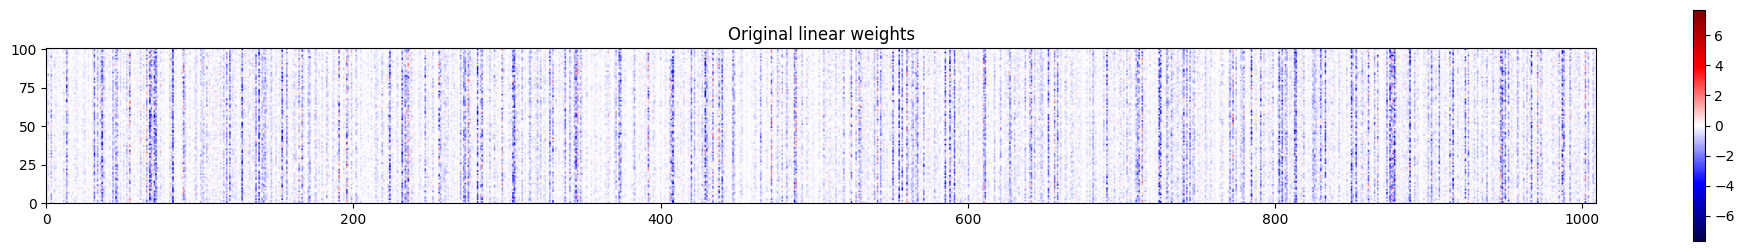

In [943]:
plot_heatmap(regnetx_3_2.fc.weight.data.cpu(), title="Original linear weights")

### Avgpool + linear weights fusing

In [901]:
print("\n3. Avgpool and linear layers fusing...\n")
weights_fused, bias_fused = fuse_avgpool_linear(regnetx_3_2, picture_size)
print("    Fused weight matrix shape:", weights_fused.shape)  # [100, 1008*H*W]


3. Avgpool and linear layers fusing...

    Fused weight matrix shape: torch.Size([100, 1008])


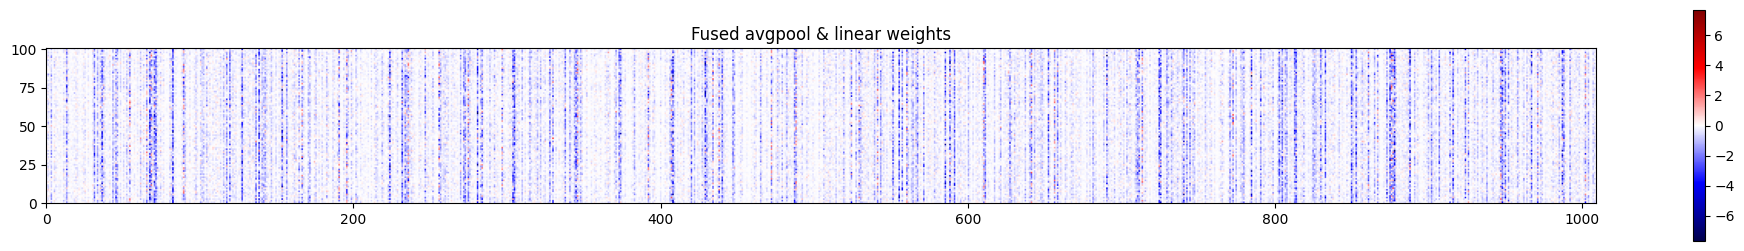

In [902]:
plot_heatmap(weights_fused.cpu(), title="Fused avgpool & linear weights")

### Significant features extraction

In [903]:
torch.manual_seed(seed)

n_svd_components = 50

print("\n4. SVD...\n")
svd = TruncatedSVD(n_components=n_svd_components, random_state=seed)
weights_reduced = svd.fit_transform(weights_fused.cpu())
print("    Explained variance ratio:", svd.explained_variance_ratio_.sum())


4. SVD...

    Explained variance ratio: 0.79665077


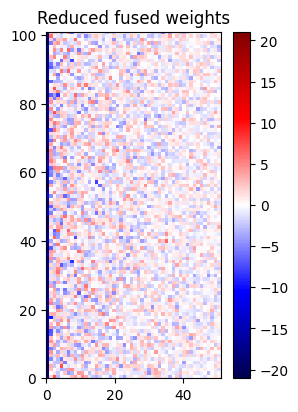

In [904]:
plot_heatmap(weights_reduced, figsize=(3, 4.5), title="Reduced fused weights")

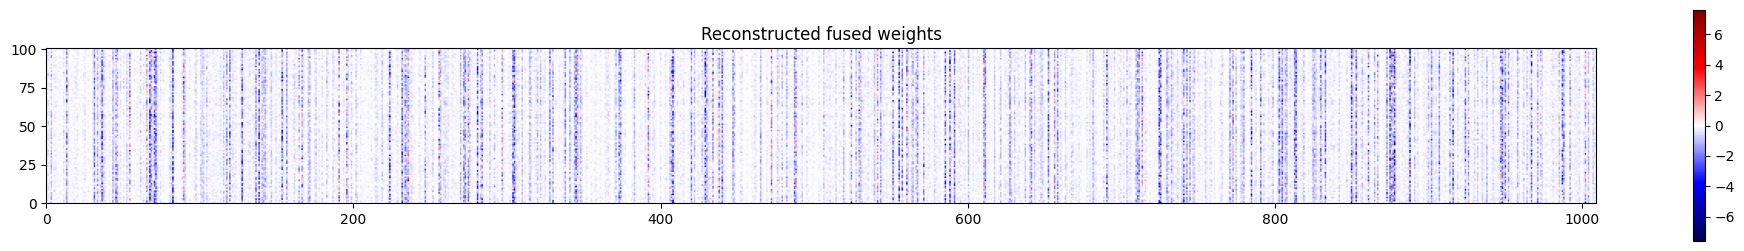

Reconstruction RMSE:      0.191770


In [905]:
svd_right_sing_vecs = svd.components_  # [n_svd_components, 1008*H*W]
weights_reconstructed = svd.inverse_transform(weights_reduced)

plot_heatmap(weights_reconstructed, title="Reconstructed fused weights")
print(f"Reconstruction RMSE:\
      {root_mean_squared_error(weights_fused.cpu().numpy(), weights_reconstructed):.6f}")

### SVD details analysis


5. Extracting significant features...



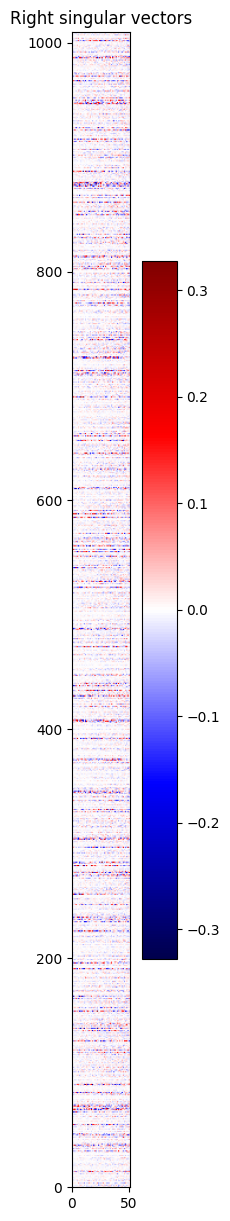

In [906]:
print("\n5. Extracting significant features...\n")

plot_heatmap(
    np.transpose(svd_right_sing_vecs), 
    figsize=(3, 15),
    title="Right singular vectors"
)

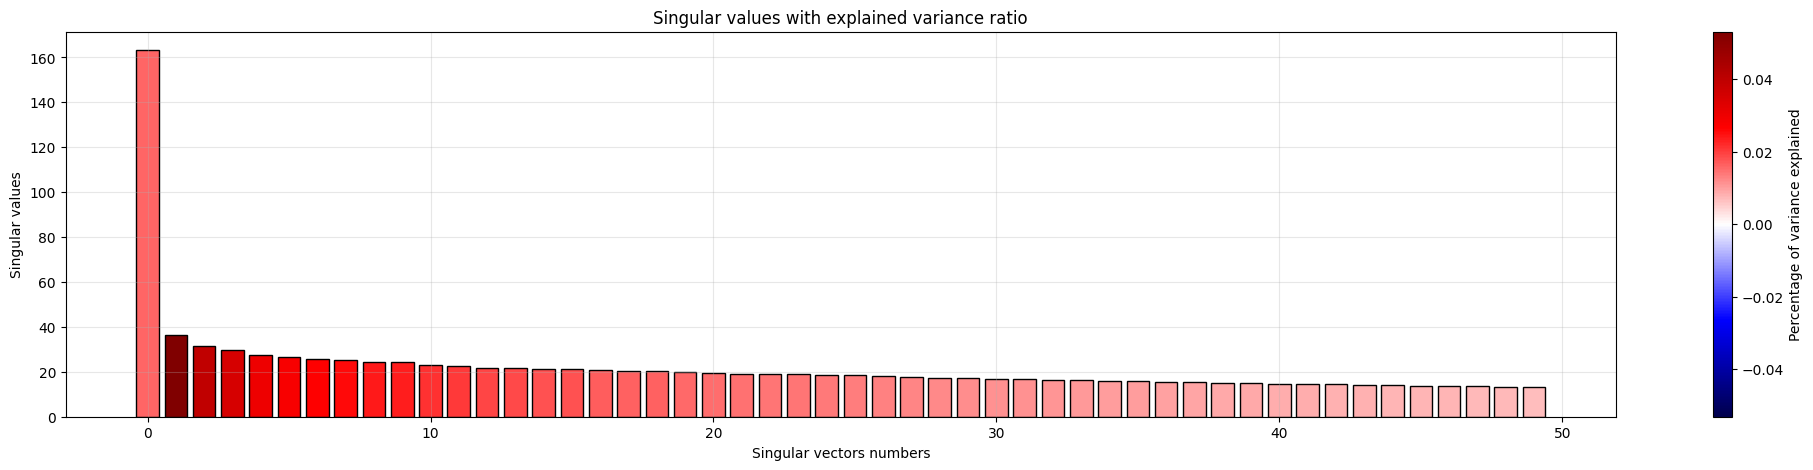

In [907]:
svd_sing_values = svd.singular_values_
svd_expl_var_ratio = svd.explained_variance_ratio_

plot_colored_barplot(
    values=svd_sing_values,
    values_color=svd_expl_var_ratio,
    title="Singular values with explained variance ratio",
    x_label="Singular vectors numbers",
    y_label="Singular values"
)

In [908]:
print("Top-5 singular values:                ", svd_sing_values[:5])
print("Top-5 (according) explained variences:", svd_expl_var_ratio[:5])

Top-5 singular values:                 [163.30693   36.425407  31.409609  29.662148  27.492422]
Top-5 (according) explained variences: [0.01590414 0.05304305 0.03938713 0.03516696 0.03021146]


### Significant features count as: singular vectors, reduced features, reconstructed features

In [732]:
def calc_ljust_spaces(signific_thresholds: list):
    n = 3
    
    thresholds_str = []
    for thr in signific_thresholds:
        thr_str = f"{thr:.{n}f}"
        thresholds_str.append(
            thr_str.rstrip('0').rstrip('.') if ('.' in thr_str) else thr_str
        )
    return thresholds_str, max(len(thr_str) for thr_str in thresholds_str) 


def signific_features_count(weights,
                            signific_thresholds: list,
                            weights_name: str = ""):
    thresholds_str, max_threshold_len = calc_ljust_spaces(signific_thresholds)

    signific_features_ns = [ np.sum(np.abs(weights) >= threshold) 
                             for threshold in signific_thresholds ]

    print(f"    Percent of significant {weights_name} features:")
    for i in range(len(signific_thresholds)):
        print(
            f"        >= {thresholds_str[i].ljust(max_threshold_len)}: ", 
            f"{signific_features_ns[i] / weights.size:.3%}"        
        )
    print("    of all features after SVD")

In [909]:
print("\n6.1 Counting significant singular features...\n")

signific_sing_thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.4]
signific_features_count(svd_right_sing_vecs, signific_sing_thresholds, "singular")


6.1 Counting significant singular features...

    Percent of significant singular features:
        >= 0.01:  45.155%
        >= 0.05:  7.774%
        >= 0.1 :  2.304%
        >= 0.15:  0.722%
        >= 0.2 :  0.173%
        >= 0.25:  0.052%
        >= 0.4 :  0.000%
    of all features after SVD


In [910]:
print("\n6.2 Counting significant reduced features...\n")

signific_red_thresholds = [0.5, 1, 2, 3, 5, 10, 15, 20, 25]
signific_features_count(weights_reduced, signific_red_thresholds, "reduced")


6.2 Counting significant reduced features...

    Percent of significant reduced features:
        >= 0.5:  79.720%
        >= 1  :  60.260%
        >= 2  :  30.660%
        >= 3  :  14.420%
        >= 5  :  3.720%
        >= 10 :  2.000%
        >= 15 :  1.480%
        >= 20 :  0.040%
        >= 25 :  0.000%
    of all features after SVD


In [911]:
print("\n6.2 Counting significant reconstructed features...\n")

signific_rec_thresholds = [0.25, 0.5, 1, 2, 3, 5, 10]
signific_features_count(
    weights_reconstructed, 
    signific_rec_thresholds, 
    "(binary in perspective) reconstructed"
)


6.2 Counting significant reconstructed features...

    Percent of significant (binary in perspective) reconstructed features:
        >= 0.25:  36.399%
        >= 0.5 :  19.976%
        >= 1   :  9.642%
        >= 2   :  2.866%
        >= 3   :  0.802%
        >= 5   :  0.058%
        >= 10  :  0.000%
    of all features after SVD


### Significant features binarization

In [961]:
print("\n7. Binarizing significant features...\n")
print("7.1 Binary weights analysis:\n")

signific_threshold = 2

filtered_weights = np.where(
    abs(weights_reconstructed) >= signific_threshold, 
    weights_reconstructed, 0
)
weights_binary = 2 ** (
    np.round(np.log2(abs(filtered_weights) + 1) * (1/2.25)) * 2.25
) - 1

filtered_weights_stats = {
    "max":  filtered_weights.max(),
    "min":  filtered_weights.min(),
    "mean": filtered_weights.mean(),
    "sdev": np.std(filtered_weights),
    "binary_values": np.unique(weights_binary)
}

print(f"    Significant (for threshold {signific_threshold}) reduced weights statistics:")
print("        max:      ", filtered_weights_stats["max"])
print("        min:      ", filtered_weights_stats["min"])
print("        mean:     ", filtered_weights_stats["mean"])
print("        deviation:", filtered_weights_stats["sdev"])
print("        binary values:", filtered_weights_stats["binary_values"])


7. Binarizing significant features...

7.1 Binary weights analysis:

    Significant (for threshold 2) reduced weights statistics:
        max:       3.002456
        min:       -7.5825534
        mean:      -0.07650459
        deviation: 0.4809851
        binary values: [0.        3.7568283]


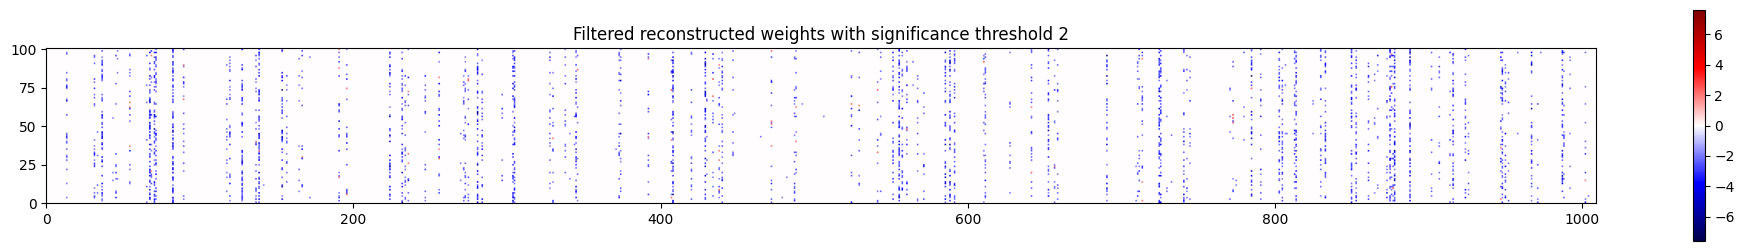

In [952]:
plot_heatmap(
    filtered_weights, 
    title=f"Filtered reconstructed weights with significance threshold {signific_threshold}"
)

    Binary features values: [0.        3.7568283]
    Binary features shape:  (100, 1008)


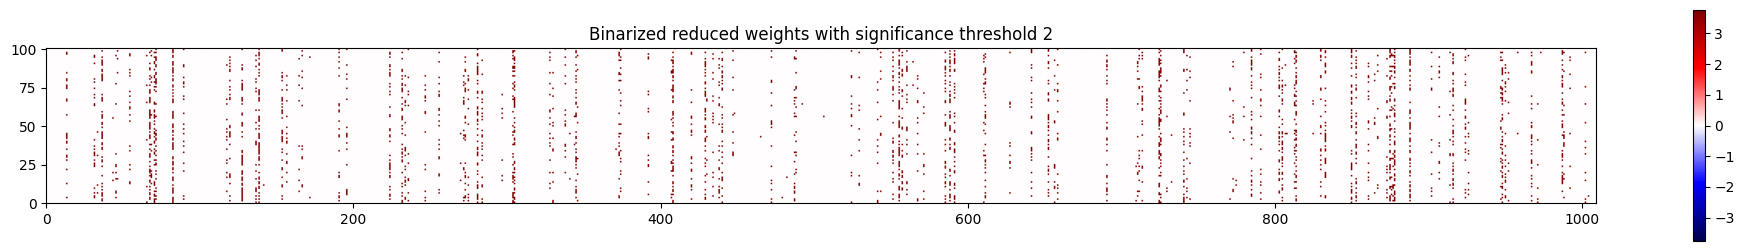

In [962]:
# weights_binary = (abs(filtered_weights) > 0).astype(int) * filtered_weights_stats["max"] * np.sign(filtered_weights_stats["mean"])
print("    Binary features values:", np.unique(weights_binary))
print("    Binary features shape: ", weights_binary.shape)

plot_heatmap(
    weights_binary, 
    title=f"Binarized reduced weights with significance threshold {signific_threshold}"
)

### Significant features semantic analysis

7.2 Significant classes per feature analysis:



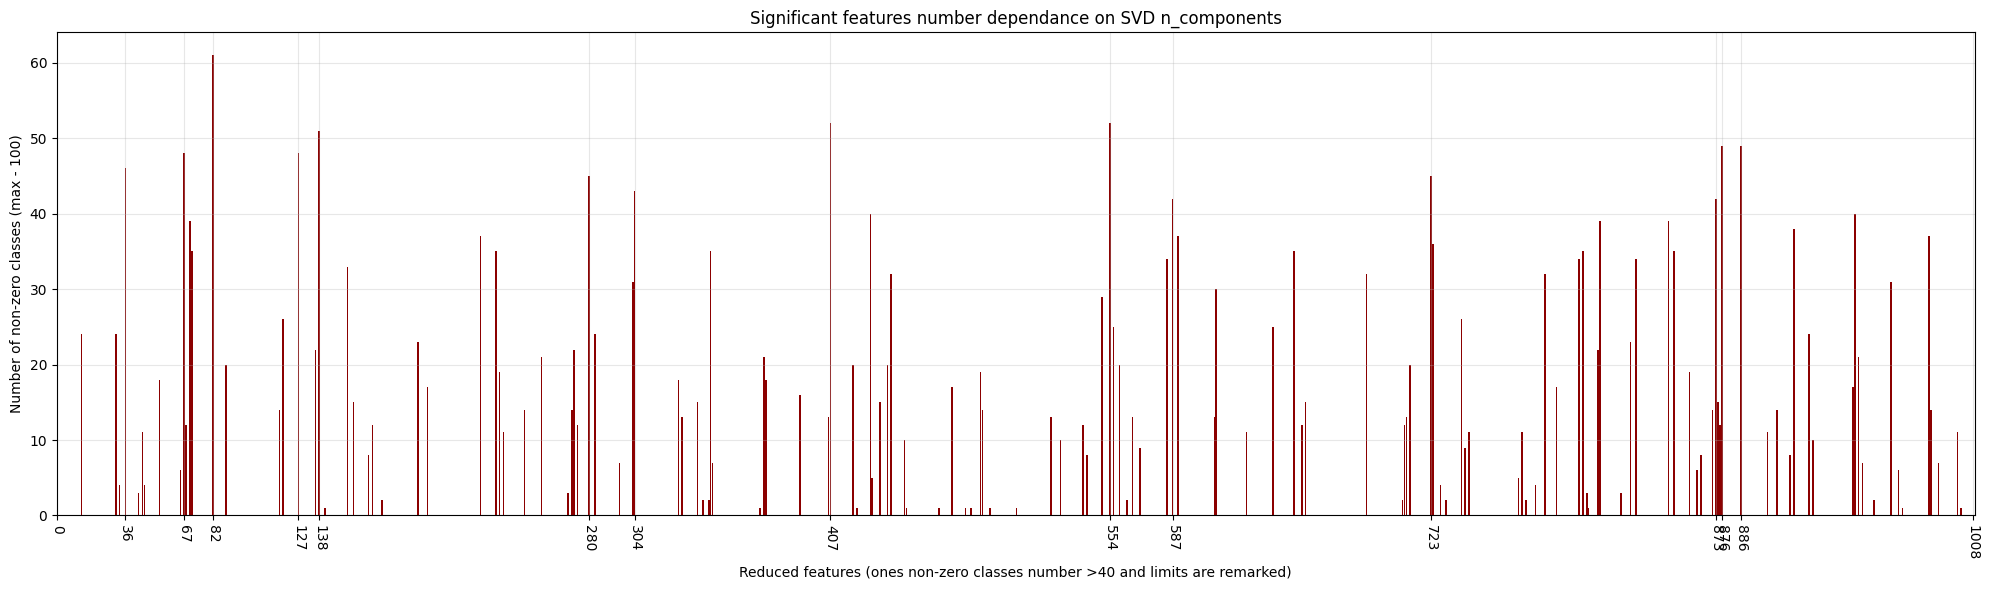

In [919]:
print("7.2 Significant classes per feature analysis:\n")

n_classes_chosen = [ np.where(weights_binary[:, feature_i])[0].size 
                     for feature_i in range(weights_binary.shape[1]) ]

n_classes_tick_limit = 40
n_largest_classes_ids = [ i for i in range(len(n_classes_chosen))
                          if (n_classes_chosen[i] > n_classes_tick_limit) ]

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(
    [i for i in range(len(n_classes_chosen))], 
    n_classes_chosen,
    color="darkred"
)

ax.set(
    xticks=n_largest_classes_ids + [0, len(n_classes_chosen)],
    xlim=(0, len(n_classes_chosen) + 1),
    xlabel=f"Reduced features (ones non-zero classes number >{n_classes_tick_limit} and limits are remarked)",
    ylabel=f"Number of non-zero classes (max - {n_classes})", 
    title="Significant features number dependance on SVD n_components"
)
ax.set_xticklabels(ax.get_xticks(), rotation=-90)
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

In [717]:
print("    The following features choose the following classes:\n")
for feature_i in range(weights_binary.shape[1]):
    if n_classes_chosen[feature_i]:
        names_chosen = [ classes_names[name_i] for name_i in np.where(weights_binary[:, feature_i])[0]]
        print(feature_i + 1, " - ", len(names_chosen), "classes: ", names_chosen)

    The following features choose the following classes:

14  -  24 classes:  ['bear', 'bridge', 'chimpanzee', 'crocodile', 'dinosaur', 'dolphin', 'fox', 'kangaroo', 'keyboard', 'lawn_mower', 'leopard', 'lion', 'lizard', 'palm_tree', 'rabbit', 'raccoon', 'shark', 'shrew', 'skunk', 'snake', 'spider', 'sweet_pepper', 'whale', 'willow_tree']
32  -  24 classes:  ['bear', 'beaver', 'bee', 'bottle', 'cloud', 'cockroach', 'couch', 'crocodile', 'dolphin', 'elephant', 'flatfish', 'fox', 'hamster', 'lamp', 'poppy', 'porcupine', 'ray', 'rocket', 'shark', 'snail', 'spider', 'tractor', 'turtle', 'wardrobe']
34  -  4 classes:  ['bee', 'boy', 'dolphin', 'lobster']
37  -  46 classes:  ['aquarium_fish', 'baby', 'beaver', 'bed', 'bee', 'bicycle', 'bowl', 'bridge', 'castle', 'cloud', 'crab', 'crocodile', 'dinosaur', 'fox', 'girl', 'house', 'kangaroo', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'motorcycle', 'mouse', 'mushroom', 'orchid', 'otter', 'palm_tree', 'pickup_truck', 'rabbit', 'raccoon

## ADD-ONS

### Add-on: SVD components search

In [718]:
torch.manual_seed(seed)

def construct_metrics_set(signific_thresholds: list):
    metrics = {}
    for threshold in signific_thresholds:
        metrics.update({ f"n_significant_features_{threshold}": [] })
    return metrics

def elbow_method_svd(weights, 
                     signific_thresholds: list,
                     components_set: list):
    metrics = construct_metrics_set(signific_thresholds)
    metrics.update({
        "explained_variances": [],
        "reconstruction_rmse": [],
        "decomposition_time": []
    })
    
    for n_components in components_set:
        start_time = time()
        svd = TruncatedSVD(n_components=n_components, random_state=seed)
        weights_reduced = svd.fit_transform(weights)
        decomp_time = time() - start_time
        weights_reconstructed = svd.inverse_transform(weights_reduced)
        
        for threshold in signific_thresholds:
            metrics[f"n_significant_features_{threshold}"].append(np.sum(np.abs(weights_reduced) >= threshold))
        metrics["decomposition_time"].append(decomp_time)
        metrics["explained_variances"].append(svd.explained_variance_ratio_.sum())
        metrics["reconstruction_rmse"].append(np.mean((weights - weights_reconstructed) ** 2))
    
    return metrics

In [719]:
n_components_options = [i for i in range(5, 105, 5)]
metrics = elbow_method_svd(
    weights_fused.cpu().t().numpy(), 
    signific_rec_thresholds,
    n_components_options
)

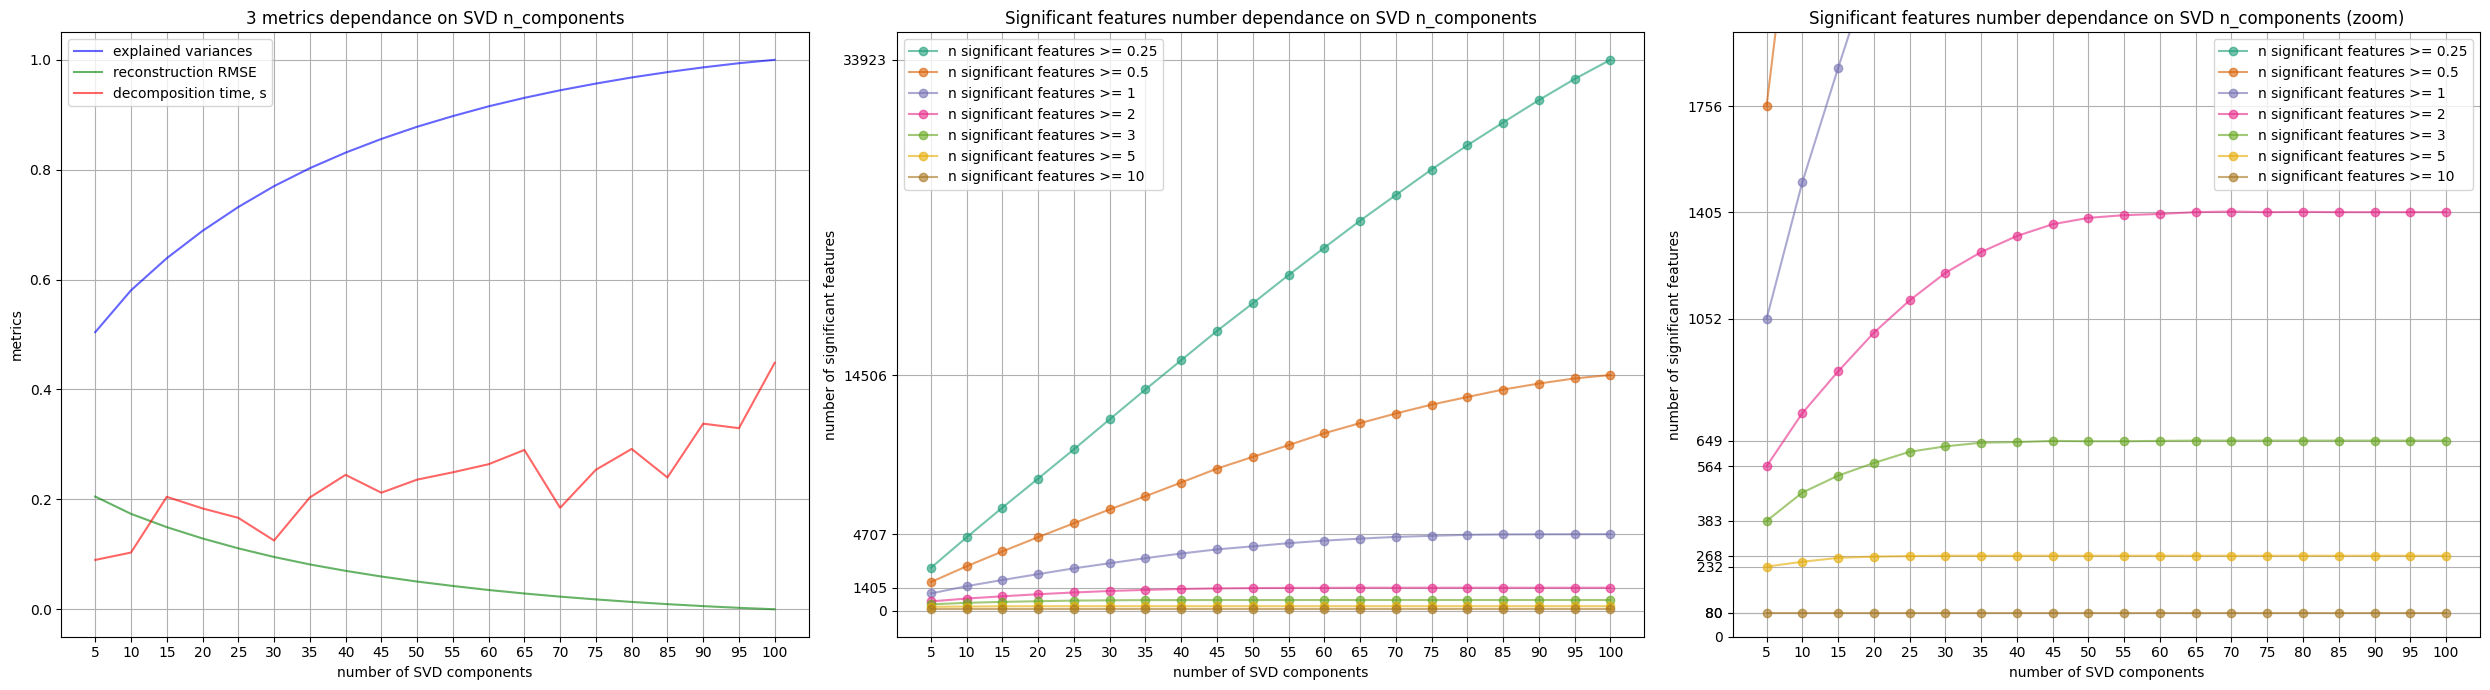

In [914]:
fig, axs = plt.subplots(1, 3, figsize=(25, 7))


axs[0].plot(n_components_options, metrics["explained_variances"], "b", alpha=0.6, label="explained variances")
axs[0].plot(n_components_options, metrics["reconstruction_rmse"], "g", alpha=0.6, label="reconstruction RMSE")
axs[0].plot(n_components_options, metrics["decomposition_time"],  "r", alpha=0.6, label="decomposition time, s")

axs[0].set(
       xticks=n_components_options,
       xlabel="number of SVD components", 
       ylabel="metrics",
       title="3 metrics dependance on SVD n_components"
)
axs[0].grid(zorder=0)
axs[0].legend()


n_components_cmap = plt.get_cmap("Dark2")
for i in range(len(signific_rec_thresholds)):
       axs[1].plot(
              n_components_options, 
              metrics[f"n_significant_features_{signific_rec_thresholds[i]}"],  
              color=n_components_cmap(i / len(signific_rec_thresholds)),
              marker="o", 
              alpha=0.6, label=f"n significant features >= {signific_rec_thresholds[i]}"
       )
axs[1].set(
       xticks=n_components_options,
       xlabel="number of SVD components", 
       yticks=[0] + [
              n_s_fs[-1] 
              for metric_name, n_s_fs in metrics.items()
              if ("n_significant_features" in metric_name) and (n_s_fs[-1] > 1000) 
       ],
       ylabel="number of significant features",
       title="Significant features number dependance on SVD n_components"
)
axs[1].grid(zorder=0)
axs[1].legend()


for i in range(len(signific_rec_thresholds)):
       axs[2].plot(
              n_components_options, 
              metrics[f"n_significant_features_{signific_rec_thresholds[i]}"],  
              color=n_components_cmap(i / len(signific_rec_thresholds)),
              marker="o", 
              alpha=0.6, label=f"n significant features >= {signific_rec_thresholds[i]}"
       )
axs[2].set(
       xticks=n_components_options,
       xlabel="number of SVD components", 
       yticks=[0] + [
              n_fs
              for metric_name, n_s_fs in metrics.items()
              if ("n_significant_features" in metric_name) 
              for n_fs in [n_s_fs[0], n_s_fs[-1]]
       ],
       ylabel="number of significant features",
       ylim=(0, 2000),
       title="Significant features number dependance on SVD n_components (zoom)"
)
axs[2].grid(zorder=0)
axs[2].legend()

plt.tight_layout()
plt.show()

In [752]:
example_signific_threshold = 3

print(f"Number of significant features >={example_signific_threshold} for each n_components option:")
for n_compts, n_sign_feats in enumerate(metrics[f"n_significant_features_{example_signific_threshold}"]):
    new_n_compts = (n_compts + 1) * 5
    
    if new_n_compts < 10: spaces = "   "
    elif new_n_compts >= 100: spaces = " "
    else: spaces = "  "
    
    print(new_n_compts, ":", spaces, n_sign_feats)

Number of significant features >=3 for each n_components option:
5 :     383
10 :    477
15 :    533
20 :    575
25 :    612
30 :    630
35 :    642
40 :    644
45 :    648
50 :    647
55 :    647
60 :    648
65 :    649
70 :    649
75 :    649
80 :    649
85 :    649
90 :    649
95 :    649
100 :   649


In [753]:
max_n_sign_features = max(metrics[f"n_significant_features_{example_signific_threshold}"])

print(f"Largest number of significant features >={example_signific_threshold}: ", max_n_sign_features)
print(
    "The n_components with this number:          ", 
    [ n_components_options[i] 
      for i in np.where(metrics[f"n_significant_features_{example_signific_threshold}"] == max_n_sign_features)[0] ]
)

Largest number of significant features >=3:  649
The n_components with this number:           [65, 70, 75, 80, 85, 90, 95, 100]


### SVD significant features number dependance on significance threshold

In [781]:
torch.manual_seed(seed)

def plot_n_signific_features_of_n_compts(weights,
                                         components_set,
                                         signific_feats_borders: tuple = (0, 25),
                                         is_reduced: bool = False,
                                         cmap_name: str = "winter",
                                         in_part: bool = False):
    fig, ax = plt.subplots(figsize=(20, 7))
    n_components_cmap = plt.get_cmap(cmap_name)

    max_n_components = max(components_set)
    thresholds = np.linspace(signific_feats_borders[0], signific_feats_borders[1], num=100)
    yticks_n_compts = []
    
    for n_components in components_set:
        svd = TruncatedSVD(n_components=n_components, random_state=seed)
        weights_reduced = svd.fit_transform(weights)
        weights_reconstructed = svd.inverse_transform(weights_reduced)
        
        if is_reduced:
            ns_signific_features = [np.sum(np.abs(weights_reduced) >= threshold) / weights_reduced.size for threshold in thresholds] \
                                   if in_part else \
                                   [np.sum(np.abs(weights_reduced) >= threshold) for threshold in thresholds]
            weights_type = "reduced"
        else:
            ns_signific_features = [np.sum(np.abs(weights_reconstructed) >= threshold) / weights_reconstructed.size for threshold in thresholds] \
                                   if in_part else \
                                   [np.sum(np.abs(weights_reconstructed) >= threshold) for threshold in thresholds]
            weights_type = "reconstructed"
                            
        ax.plot(
            thresholds,
            ns_signific_features,
            color=n_components_cmap(n_components / max_n_components),
            alpha=0.6,
            label=f"n_signific_features with {n_components} SVD components"
        )
        yticks_n_compts.append(ns_signific_features[0])

    if in_part:
        yticks_n_compts = [i * (max(yticks_n_compts) / 20) for i in range(0, 21)]
    else:
        yticks_n_compts = [0] + yticks_n_compts \
                          if (len(components_set) >= 10) else \
                          [i * (max(yticks_n_compts) // 10) for i in range(0, 11)]
    xticks_n_compts = [i for i in range( int(signific_feats_borders[0]), int(signific_feats_borders[1]) + 1 )] \
                      if (signific_feats_borders[1] > 3) else \
                      [i / 10 for i in range( int(signific_feats_borders[0])*10, int(signific_feats_borders[1])*10 + 1 )]
    
    scaling_name = "Part" if in_part else "Number"
    ax.set(
        xticks=xticks_n_compts,
        xlabel="Significance thresholds",
        yticks=yticks_n_compts,
        ylabel=scaling_name + " of significant features",
        title=scaling_name + f" of {weights_type} significant features dependance on SVD n_components"
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()
    plt.show()

#### Lots of graphs

In [775]:
signific_borders=(0, 25)
signific_borders_zoom=(0, 6)
signific_borders_extrazoom=(0, 2)

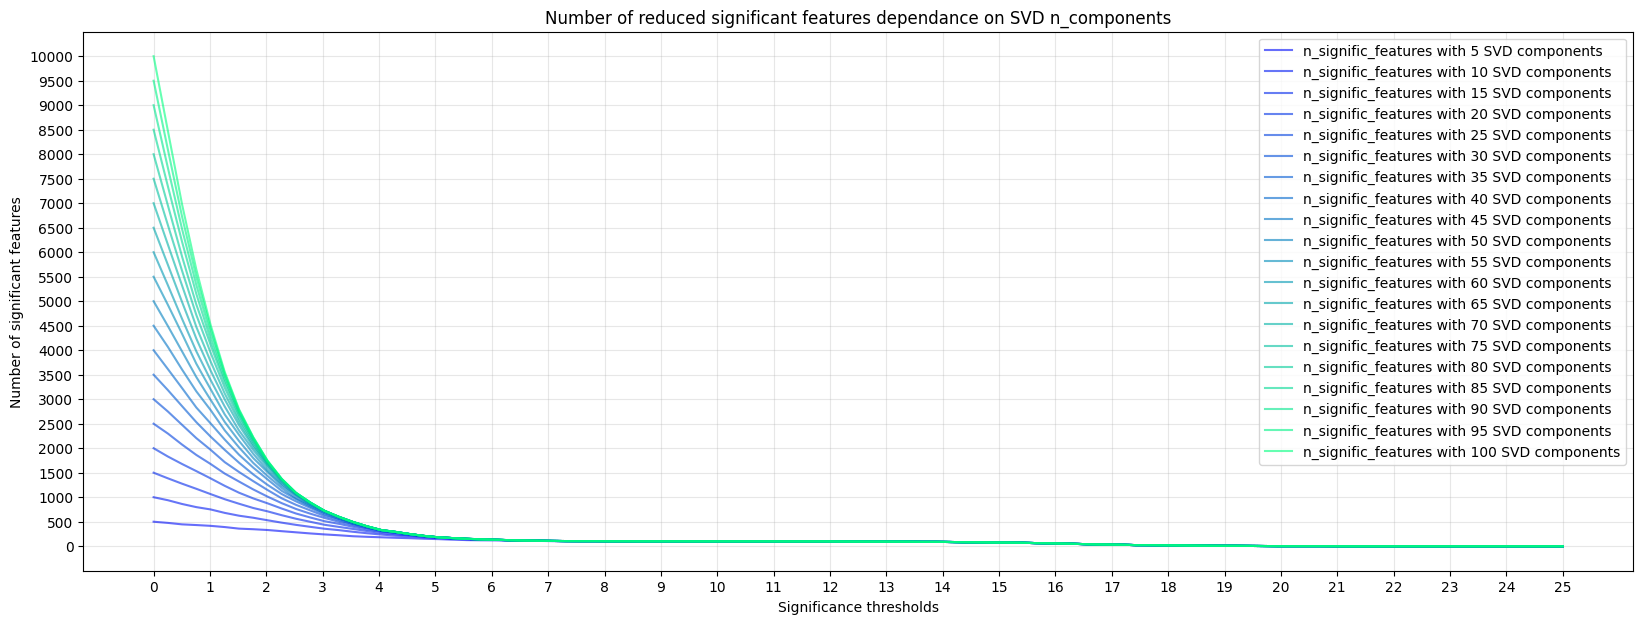

In [768]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=n_components_options,
    is_reduced=True,
    signific_feats_borders=signific_borders
)

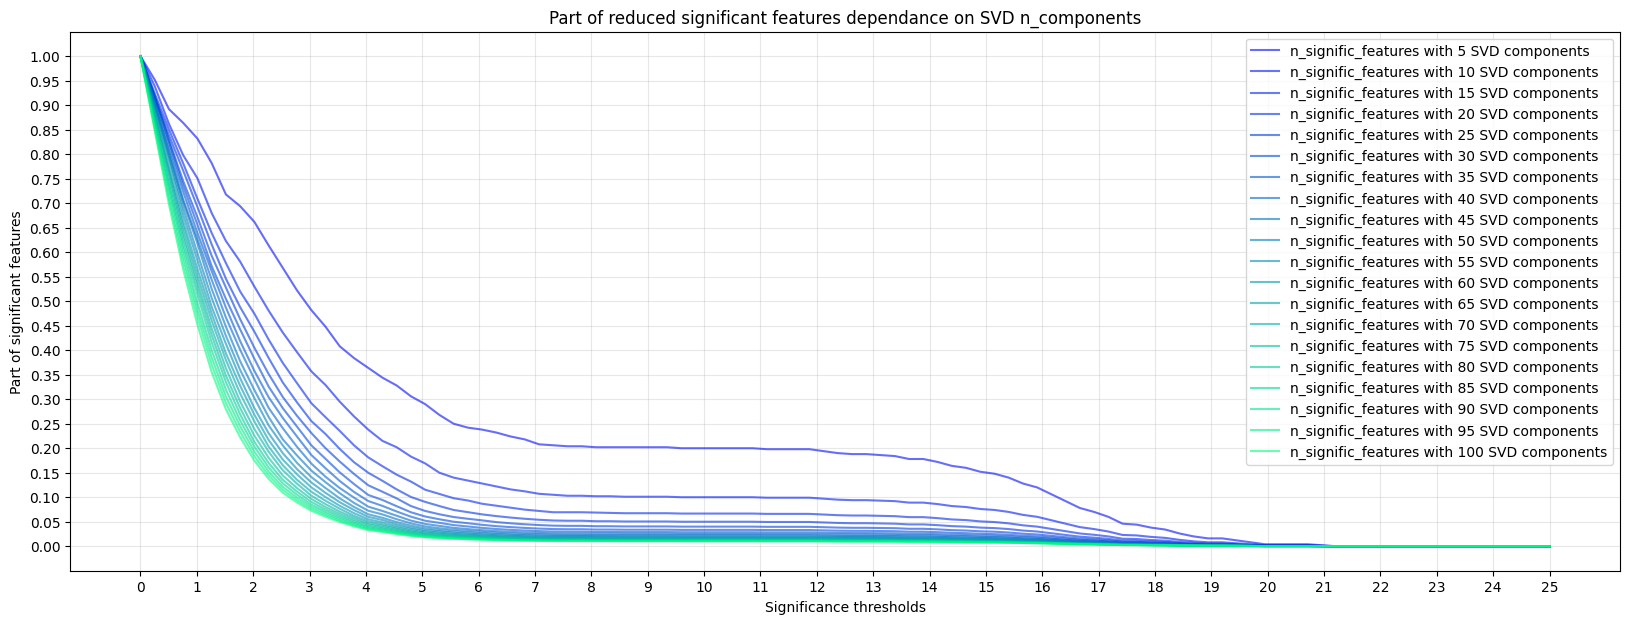

In [769]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=n_components_options,
    is_reduced=True,
    signific_feats_borders=signific_borders,
    in_part=True
)

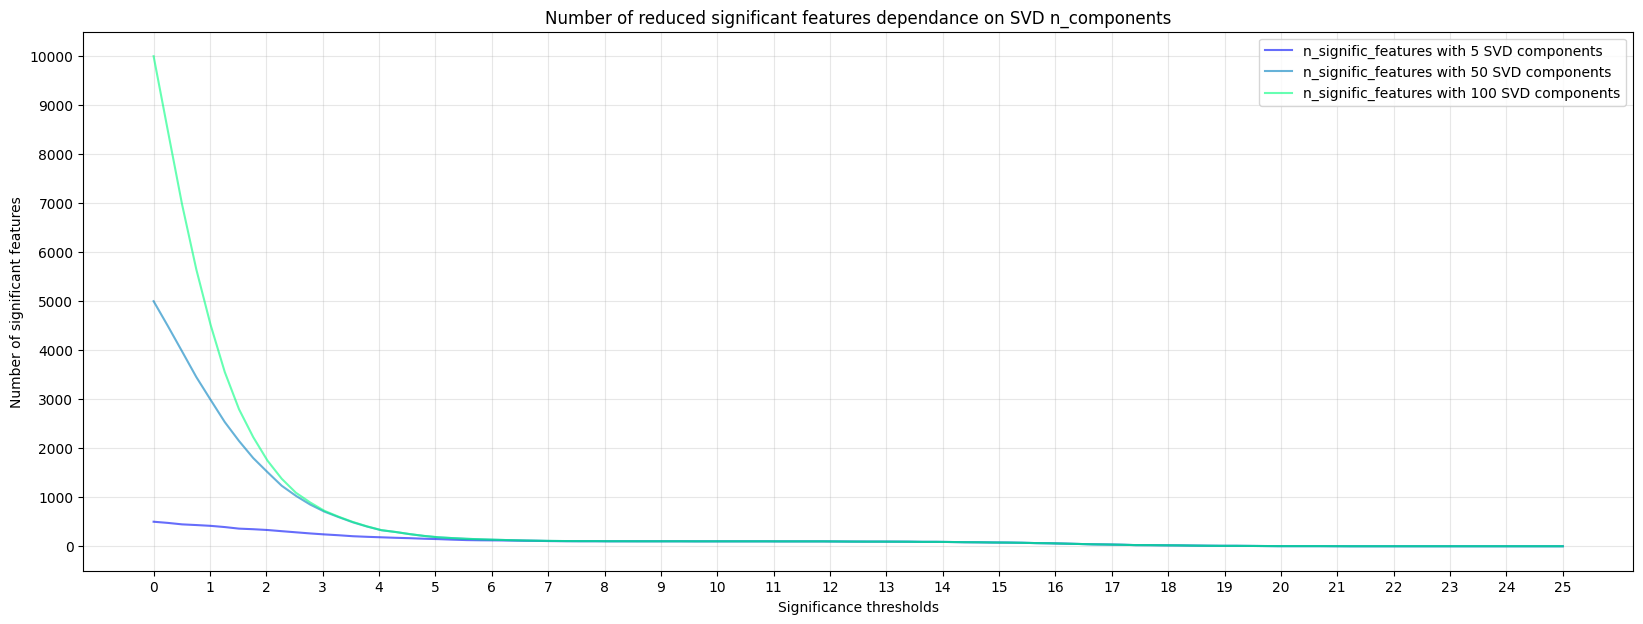

In [770]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=[5, 50, 100],
    is_reduced=True,
    signific_feats_borders=signific_borders
)

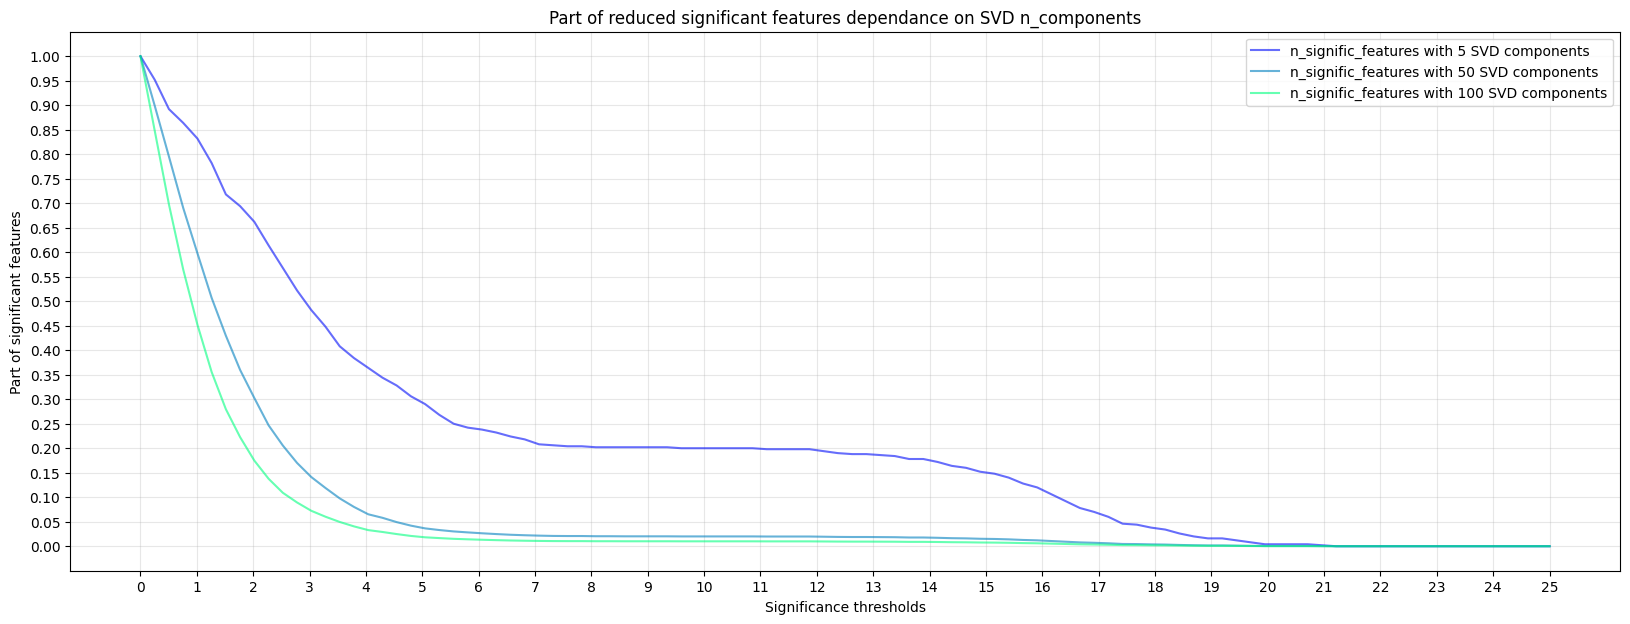

In [771]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=[5, 50, 100],
    is_reduced=True,
    signific_feats_borders=signific_borders,
    in_part=True
)

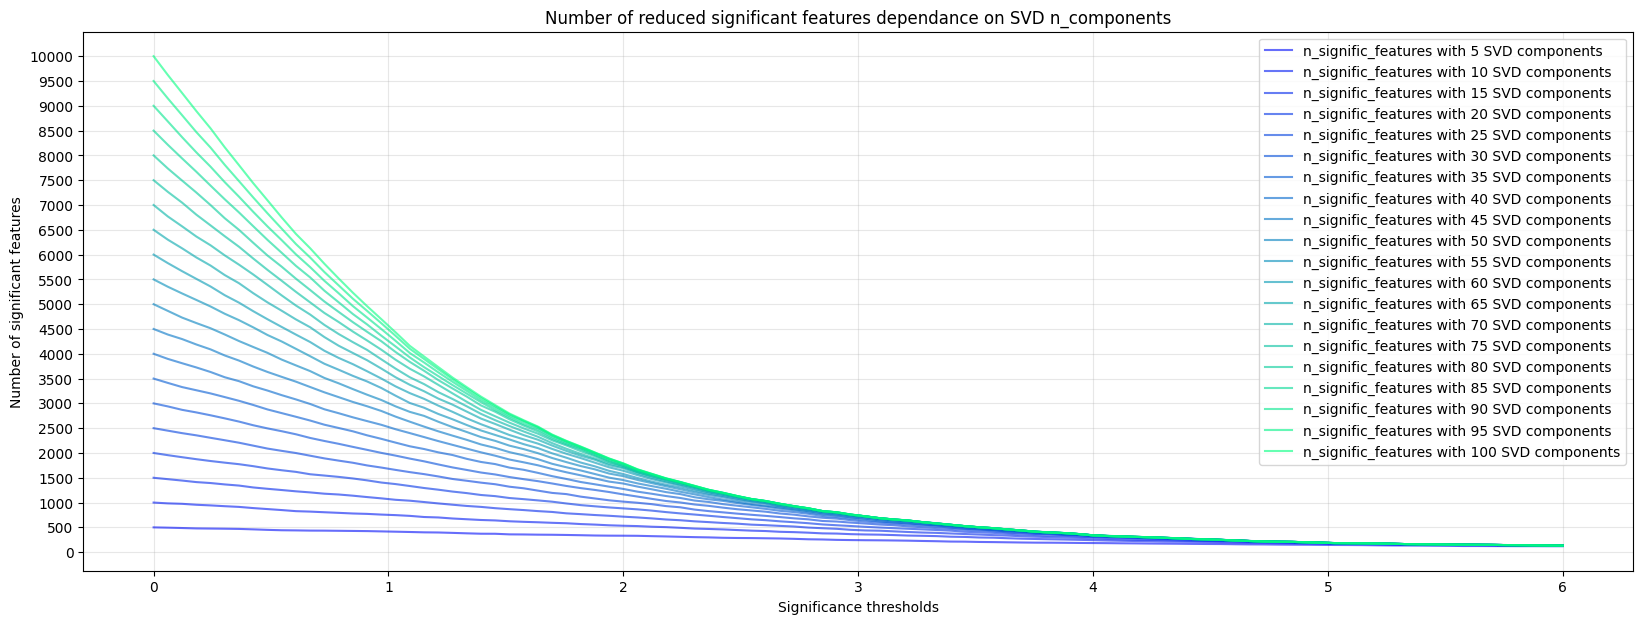

In [772]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=n_components_options,
    is_reduced=True,
    signific_feats_borders=signific_borders_zoom
)

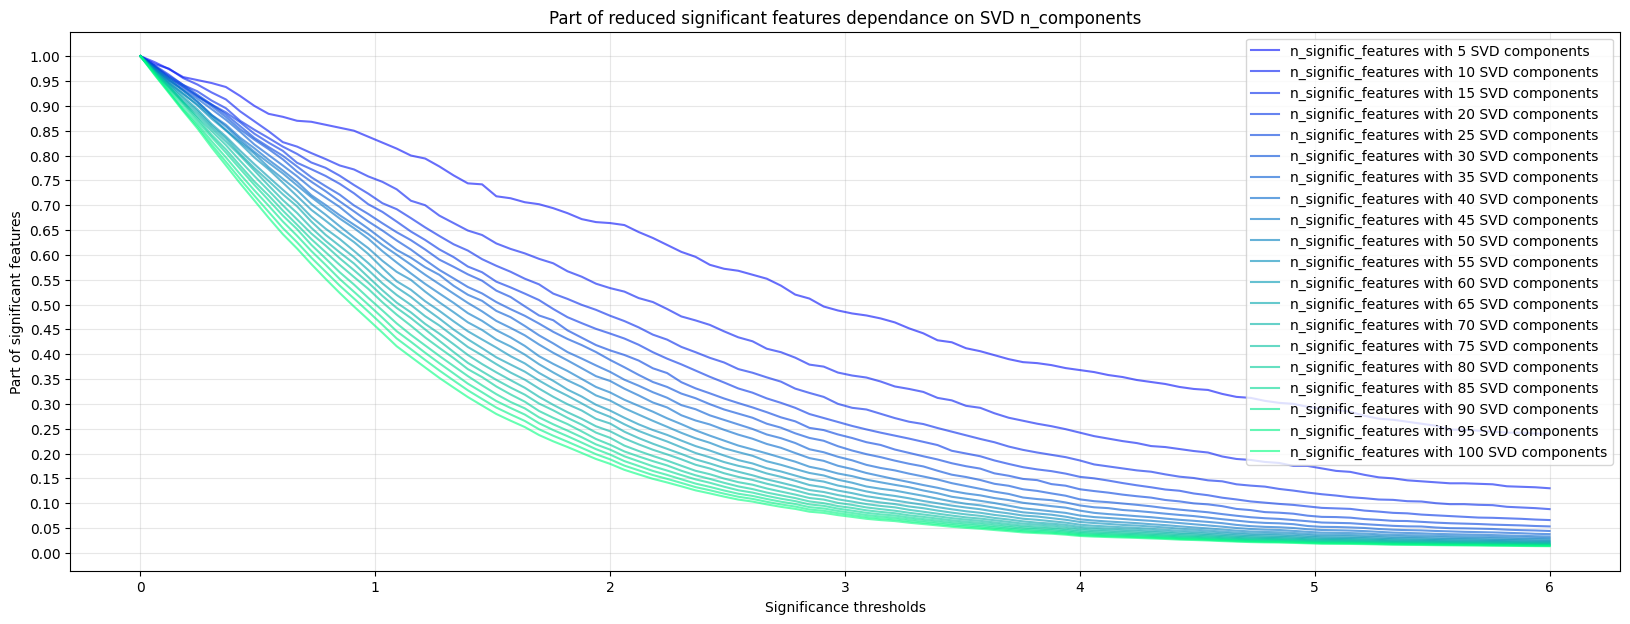

In [773]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=n_components_options,
    is_reduced=True,
    signific_feats_borders=signific_borders_zoom,
    in_part=True
)

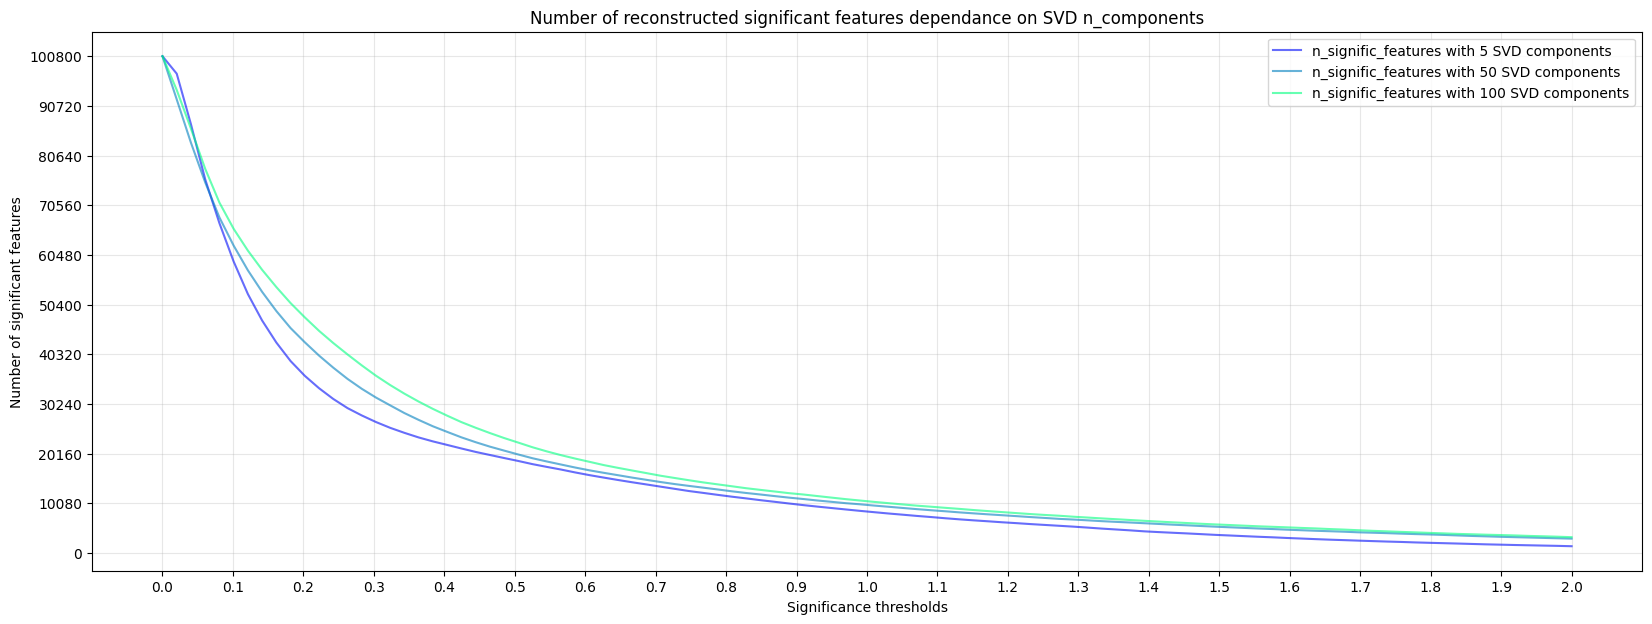

In [783]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=[5, 50, 100],
    signific_feats_borders=signific_borders_extrazoom,
    in_part=False
)

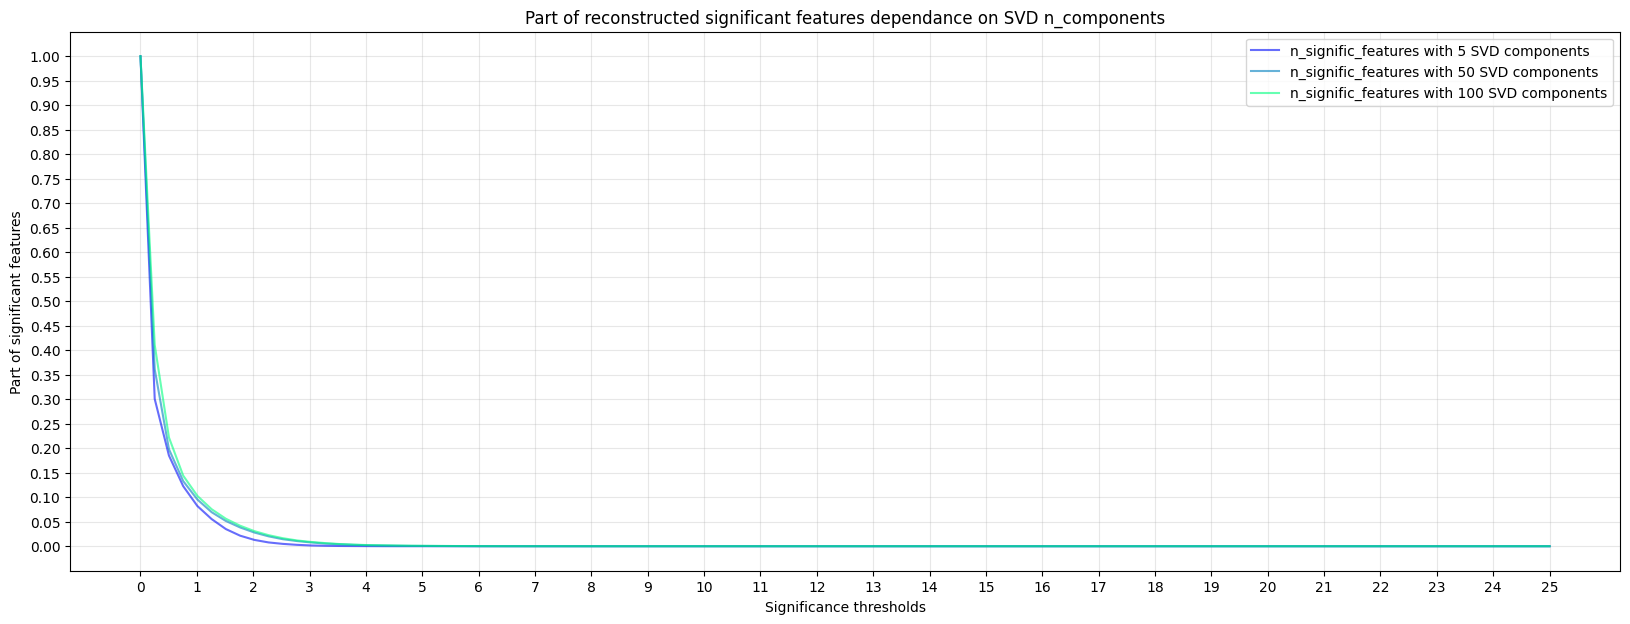

In [767]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=[5, 50, 100],
    signific_feats_borders=signific_borders,
    in_part=True
)

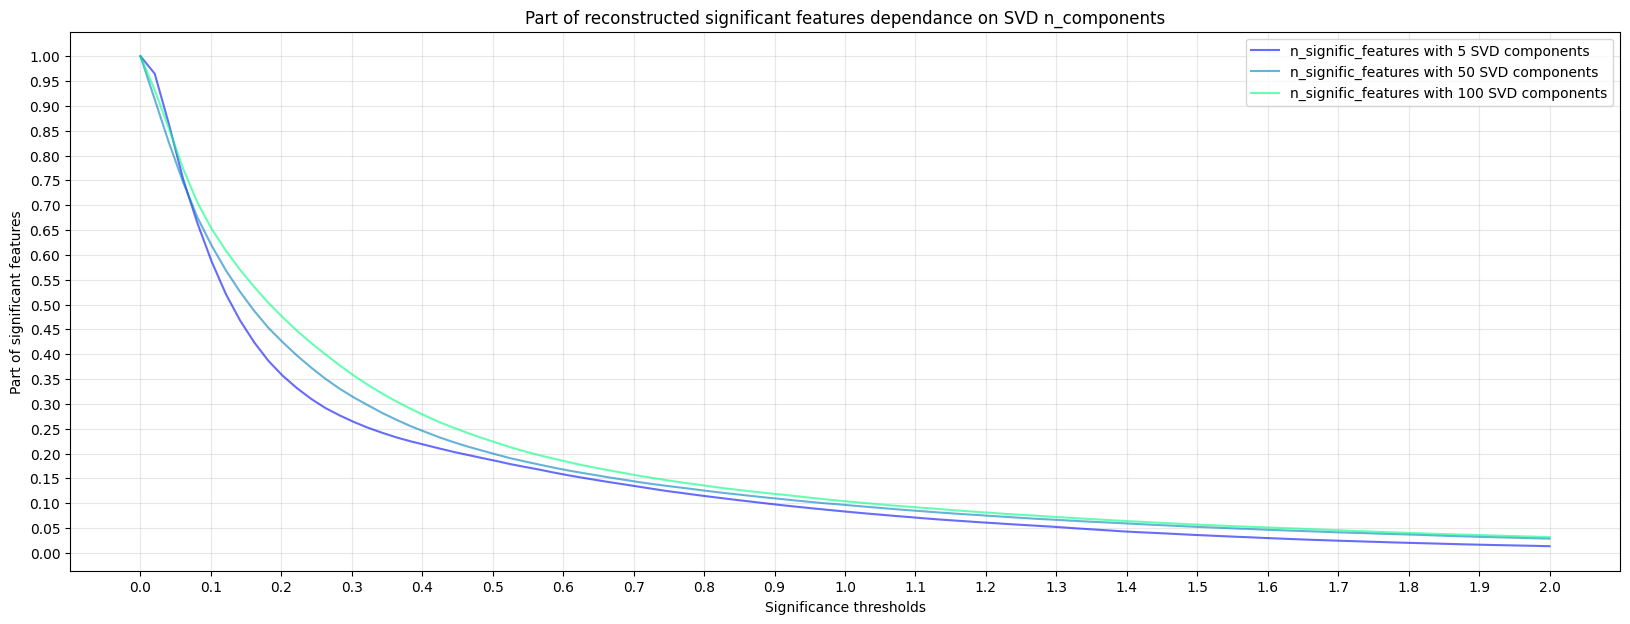

In [782]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().numpy(), 
    components_set=[5, 50, 100],
    signific_feats_borders=signific_borders_extrazoom,
    in_part=True
)

### Binarization function choice

In [ ]:
def binarize_hook_choice(module, input):
    x, = input
    x_pseudobin = 2 ** (x+1).log2().mul(1/scale_k).round().mul(scale_k) - 1 # type: ignore
    # x_pseudobin = 2 ** (x+1).log2().round() - 1                  #-0.1%  for ResNet50 on CIFAR-10
    # x_pseudobin = 2 ** (x+1).log2().mul(2).round().mul(0.5) - 1  #-0.01% for ResNet50 on CIFAR-10

    print("Binarization gives", len(x_pseudobin.unique()), "values")
    print(x_pseudobin.unique(return_counts=True))
    return (x_pseudobin,) 

In [ ]:
print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
checkpoint = torch.load(checkpoint_path)
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"], "\n")

print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device 
)


[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34 

[ ] Validating model before binarizing:
    Top-1 Accuracy:  57.34
    Top-5 Accuracy:  81.0
    Validation time: 10.012861967086792
[V] Model validated


In [ ]:
top1_bins, top5_bins, drops1, drops5 = {}, {}, {}, {}

for scale in range(1, 21):
    scale_k = scale/4
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    regnetx_3_2 = models.regnet_x_3_2gf()
    adapt_model_cifar100(regnetx_3_2, n_classes)
    regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
    regnetx_3_2.to(device)
    print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

    print("\n[ ] Binarizing avgpool input...")
    regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print("[V] Avgpool input binarized into values:", bin_values)

    print("\nValidating model after binarizing avgpool input:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig, 
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 0.25:

[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34

[ ] Binarizing features...
[V] Features binarized

[ ] Validating model after binarizing:
Binarizatin gives 21 values
(tensor([ 0.0000,  0.1892,  0.4142,  0.6818,  1.0000,  1.3784,  1.8284,  2.3636,
         3.0000,  3.7568,  4.6569,  5.7272,  7.0000,  8.5137, 10.3137, 12.4543,
        15.0000, 18.0273, 21.6274, 25.9087, 31.0000], device='cuda:0'), tensor([512243,    235,    233,    225,    259,    262,    319,    352,    306,
           293,    292,    273,    241,    193,    142,    112,     61,     33,
            12,      9,      1], device='cuda:0'))
Binarizatin gives 22 values
(tensor([ 0.0000,  0.1892,  0.4142,  0.6818,  1.0000,  1.3784,  1.8284,  2.3636,
         3.0000,  3.7568,  4.6569,  5.7272,  7.0000,  8.5137, 10.3137, 12.4543,
        15.0000, 18.0273, 21.6274, 25.9087, 31.0000, 37.0546], device='cuda:0'), tensor([512204

In [ ]:
for scale in range(32, 49):
    scale_k = scale/8
    if scale_k in drops1.keys():
        continue
    
    print(f"\n\nBinarization with coeff {scale_k}:")
    
    print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    regnetx_3_2 = models.regnet_x_3_2gf()
    adapt_model_cifar100(regnetx_3_2, n_classes)
    regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
    regnetx_3_2.to(device)
    print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

    print("\n[ ] Binarizing features...")
    regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook_choice)
    print("[V] Features binarized")

    print("\nValidating model after binarizing:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig,
        top5_orig=top5_orig
    )
    
    top1_bins[scale_k] = top1_bin
    drops1[scale_k] = drop1
    top5_bins[scale_k] = top5_bin
    drops5[scale_k] = drop5



Binarization with coeff 5.125:

[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34

[ ] Binarizing features...
[V] Features binarized

[ ] Validating model after binarizing:
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514997,   1099], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514990,   1106], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([515016,   1080], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514928,   1168], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514984,   1112], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], device='cuda:0'), tensor([514993,   1103], device='cuda:0'))
Binarizatin gives 2 values
(tensor([ 0.0000, 33.8962], devi

In [ ]:
scale_ks = sorted(drops1.keys())
drops1_truebin = { scale_k: drops1[scale_k] for scale_k in scale_ks if (scale_k >= 4) }
drops5_truebin = { scale_k: drops5[scale_k] for scale_k in scale_ks if (scale_k >= 4) }

drop1_min = min(drops1_truebin.values())
drop5_min = min(drops5_truebin.values())
list(filter(lambda k: drops5[k] == drop5_min, drops5_truebin))

print(f"Minimal top-1 accuracy drop {drop1_min:.2f}", 
      " is achieved with scaling coeff ", 
      list(filter(lambda k: drops1[k] == drop1_min, drops1_truebin)))
print(f"Minimal top-5 accuracy drop {drop5_min:.2f} ", 
      " is achieved with scaling coeff ", 
      list(filter(lambda k: drops5[k] == drop5_min, drops5_truebin)))

Minimal top-1 accuracy drop 9.91  is achieved with scaling coeff  [4.625]
Minimal top-5 accuracy drop 8.85   is achieved with scaling coeff  [4.75]


In [884]:
drops1_truebin

{4.0: 10.970000000000006,
 4.125: 10.500000000000007,
 4.25: 10.600000000000009,
 4.375: 10.260000000000005,
 4.5: 10.060000000000002,
 4.625: 9.910000000000004,
 4.75: 10.050000000000004,
 4.875: 10.260000000000005,
 5.0: 10.500000000000007,
 5.125: 11.07,
 5.25: 11.590000000000003,
 5.375: 12.240000000000002,
 5.5: 12.950000000000003,
 5.625: 13.5,
 5.75: 14.330000000000005,
 5.875: 15.590000000000003,
 6.0: 17.010000000000005}

In [888]:
def plot_scale_k_metrics(metric_dicts: list[dict],
                         metric_names: list[str],
                         cmap_name: str = "winter"):
    fig, ax = plt.subplots(figsize=(20, 7))
    metric_cmap = plt.get_cmap(cmap_name)
    
    for i, metric_dict in enumerate(metric_dicts):
        scale_ks = sorted(metric_dict.keys())
        metric_values = [metric_dict[scale_k] for scale_k in scale_ks]
        
        ax.plot(
            scale_ks, 
            metric_values, 
            marker='o', 
            color=metric_cmap(i / len(metric_dicts)),
            label=metric_names[i]
        )
        
    ax.set(
        xticks=scale_ks,
        xlabel="Scaling coefficient",
        yticks=[i for i in range(0, 86, 5)],
        ylabel="Accuracy (in %)",
        title="Accuracy dependence on scaling coefficient"
    )
    ax.set_xticklabels(ax.get_xticks(), rotation=-45)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.tight_layout()
    plt.show()

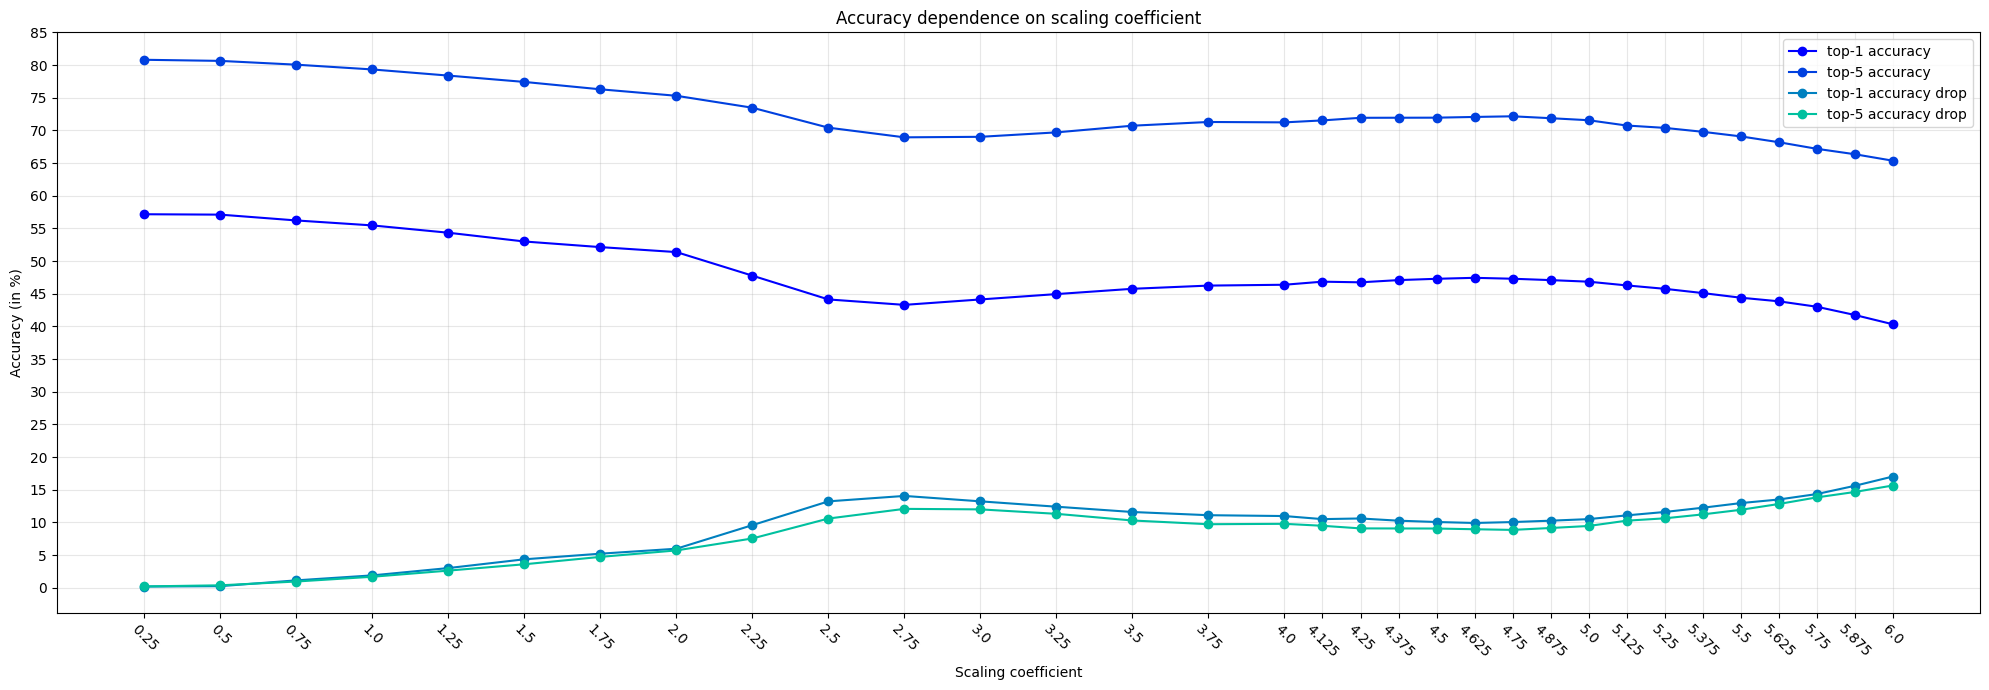

In [889]:
plot_scale_k_metrics(
    [top1_bins, top5_bins, drops1, drops5],
    ["top-1 accuracy", "top-5 accuracy", "top-1 accuracy drop", "top-5 accuracy drop"]
)

### Model performance dependance on binarization type

In [976]:
print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
checkpoint = torch.load(checkpoint_path)
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader, device 
)


[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34

Validating model before binarizing:
    Top-1 Accuracy:  57.3400
    Top-5 Accuracy:  81.0000
    Validation time: 10.039460897445679


In [981]:
def calc_binary_weights_options(filtered_weights):
    naive_bool_weights = (abs(filtered_weights) > 0).astype(int)
    return {
        "naive_bool":  naive_bool_weights,
        "signed_bool": naive_bool_weights * np.sign(filtered_weights_stats["mean"]),
        "naive_mean":  naive_bool_weights * filtered_weights_stats["mean"],
        "naive_min":   naive_bool_weights * filtered_weights_stats["min"],
        "signed_max": naive_bool_weights * \
                      filtered_weights_stats["max"] * \
                      np.sign(filtered_weights_stats["mean"]),
        "smart_function": 2 ** (
                              np.round(np.log2(abs(filtered_weights) + 1) * (1/2.25)) * 2.25
                          ) - 1,
        "signed_smart_function": (2 ** (
                              np.round(np.log2(abs(filtered_weights) + 1) * (1/2.25)) * 2.25
                          ) - 1) * np.sign(filtered_weights_stats["mean"])
    }

In [982]:
binary_weights_options = calc_binary_weights_options(filtered_weights)

In [ ]:
top1_fused_bins, top5_fused_bins, drops1_fused, drops5_fused = {}, {}, {}, {}

for bin_option in binary_weights_options.keys():
    print("\n\nValidation with binarization:", bin_option)
    
    print("\n[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    regnetx_3_2 = models.regnet_x_3_2gf()
    adapt_model_cifar100(regnetx_3_2, n_classes)
    regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
    regnetx_3_2.to(device)
    print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])
    
    print("\n[ ] Binarizing avgpool input...")
    regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook)
    print("[V] Avgpool input binarized")
    
    print("\nValidating model after binarizing avgpool input:")
    top1_orig_bin, top5_orig_bin, _, _, _ = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig, 
        top5_orig=top5_orig
    )

    print("[ ] Binarizing weights...")
    replace_linear(regnetx_3_2, binary_weights_options[bin_option])
    print("[V] Fused layer binarized into values:", regnetx_3_2.fc.weight.data.unique())

    print(f"\nValidating model after fused layer binarization:")
    top1_bin, top5_bin, val_time, drop1, drop5 = pretty_print_top1_top5_time(
        regnetx_3_2, val_loader, device, 
        top1_orig=top1_orig_bin,
        top5_orig=top5_orig_bin
    )
    
    top1_fused_bins[bin_option] = top1_bin
    drops1_fused[bin_option] = drop1
    top5_fused_bins[bin_option] = top5_bin
    drops5_fused[bin_option] = drop5



Validation with binarization: naive_bool

[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34

[ ] Binarizing avgpool input...
[V] Avgpool input binarized into values: tensor([ 0.0000, 23.6754], device='cuda:0')

Validating model after binarizing avgpool input:
    Top-1 Accuracy:  47.4300, drop: 9.9100
    Top-5 Accuracy:  72.0500, drop: 8.9500
    Validation time: 9.976322650909424
[ ] Binarizing weights...
[V] Fused layer binarized into values: tensor([0., 1.], device='cuda:0')

Validating model after fused layer binarization:
    Top-1 Accuracy:  0.0500, drop: 47.3800
    Top-5 Accuracy:  0.6600, drop: 71.3900
    Validation time: 9.951338768005371


Validation with binarization: signed_bool

[ ] Loading original fine-tuned model for CIFAR-100 from checkpoint...
[V] Fine-tuned model loaded, its accuracy: 57.34

[ ] Binarizing avgpool input...
[V] Avgpool input binarized into values: tensor([ 0.0000, 23.6754], dev

In [984]:
drops1_fused

{'naive_bool': 47.38,
 'signed_bool': 44.79,
 'naive_mean': 45.23,
 'naive_min': 44.79,
 'signed_max': 44.79,
 'smart_function': 47.38,
 'signed_smart_function': 44.79}

## ARCHIVE

### ResNet50 binarization check

ResNet50 weights for CIFAR-10 are taken from https://github.com/huyvnphan/PyTorch_CIFAR10

In [ ]:
print("[ ] Instantiating model...")
resnet50 = models.resnet50(progress=True)
resnet50.conv1 = torch.nn.Conv2d(3, 64, 3, 3, bias=True)
resnet50.fc = torch.nn.Linear(2048, 10)

checkpoint_path_resnet = "checkpoints/resnet50.pt"
checkpoint_resnet = torch.load(checkpoint_path_resnet)
resnet50.load_state_dict(checkpoint_resnet, strict=False)

resnet50.to(device)
resnet50_name = "ResNet50"
print(f"[V] Model {resnet50_name} instantiated and adapted for CIFAR-100")

[ ] Instantiating model...
[V] Model ResNet50 instantiated and adapted for CIFAR-100


In [ ]:
print("\n2. Binarizing features...\n")
resnet50.avgpool.register_forward_pre_hook(binarize_hook)

print("\n2.5. Validating model after binarizing:\n")
top1_bin, top5_bin, val_time = validate_top1_top5_time(resnet50, val_loader, device)
print(f"    Top-1 Accuracy: {top1_bin:.4f}")
print(f"    Top-5 Accuracy: {top5_bin:.4f}")
print("    Validation time:", val_time)


2. Binarizing features...


2.5. Validating model after binarizing:

(tensor([0., 1.], device='cuda:0'), tensor([262139,      5], device='cuda:0'))
(tensor([0.], device='cuda:0'), tensor([262144], device='cuda:0'))
(tensor([0.], device='cuda:0'), tensor([262144], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([262143,      1], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([262138,      6], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([262140,      4], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([262133,     11], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([262126,     18], device='cuda:0'))
(tensor([0.], device='cuda:0'), tensor([262144], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([262141,      3], device='cuda:0'))
(tensor([0.], device='cuda:0'), tensor([262144], device='cuda:0'))
(tensor([0.], device='cuda:0'), tensor([262144], device='cuda:0'))
(tensor([0.], device='cuda:0'), tensor([26

### Significant classes' semantics analysis

ARCHIVED as the classes change completely with slight performance change.

In [14]:
top_classes_significance = mostleast_signific_classes(weights_fused.cpu().numpy(), 0, val_loader)
top_classes_significance["top_classes_ids"], top_classes_significance["top_classes_names"], \
top_classes_significance["bottom_classes_ids"], top_classes_significance["bottom_classes_names"]

(array([35, 69, 65, 93, 78]),
 ['girl', 'rocket', 'rabbit', 'turtle', 'snake'],
 array([87,  6, 91, 24, 37]),
 ['television', 'bee', 'trout', 'cockroach', 'house'])

In [15]:
def display_classes_examples(dataloader, classes_ids, n_examples: int=3):  
    classes_names = [dataloader.dataset.classes[class_id] for class_id in classes_ids]
    classes = {
        class_id: class_name
        for class_id, class_name in zip(classes_ids, classes_names)
    }
    images_to_show = []
    captions = []
    
    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            for image, label in zip(batch_images, batch_labels):
                label_num = label.item()
                if label_num in classes_ids:
                    class_name = classes[label_num]
                    if captions.count(class_name) < n_examples:
                        images_to_show.append(image)
                        captions.append(class_name)
            
            if all(captions.count(class_id) >= n_examples for class_id in classes_ids):
                break
    
    fig, axes = plt.subplots(
        len(classes_ids), 
        n_examples, 
        figsize=(n_examples * 2, len(classes_names) * 2)
    )
    
    for i, class_name in enumerate(classes_names):
        indices = [id for id, caption in enumerate(captions) if (caption == class_name)][:n_examples]
        
        for j, idx in enumerate(indices):
            ax = axes[i][j]
            image = images_to_show[idx].numpy().transpose(1, 2, 0)
            
            mean = [0.5071, 0.4867, 0.4408]
            std = [0.2675, 0.2565, 0.2761]
            image = std * image + mean
            image = np.clip(image, 0, 1)
            
            ax.imshow(image)
            ax.set_xticks([])
            ax.set_yticks([])
            
            if j == 0:
                ax.set_ylabel(class_name, rotation=0, ha='right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

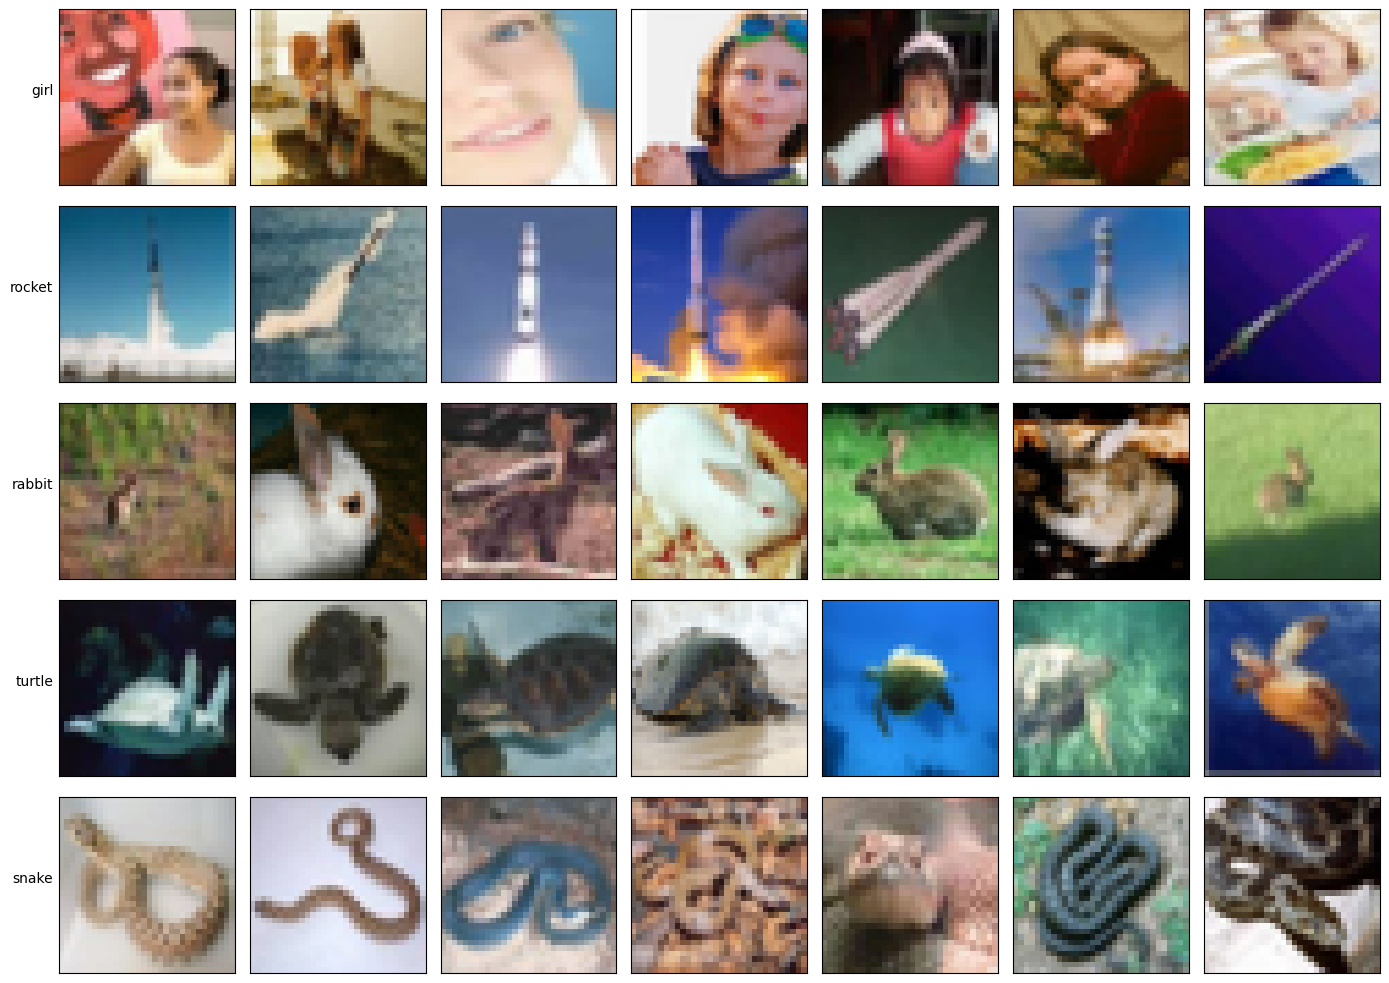

In [18]:
display_classes_examples(val_loader, top_classes_significance["top_classes_ids"], 7)

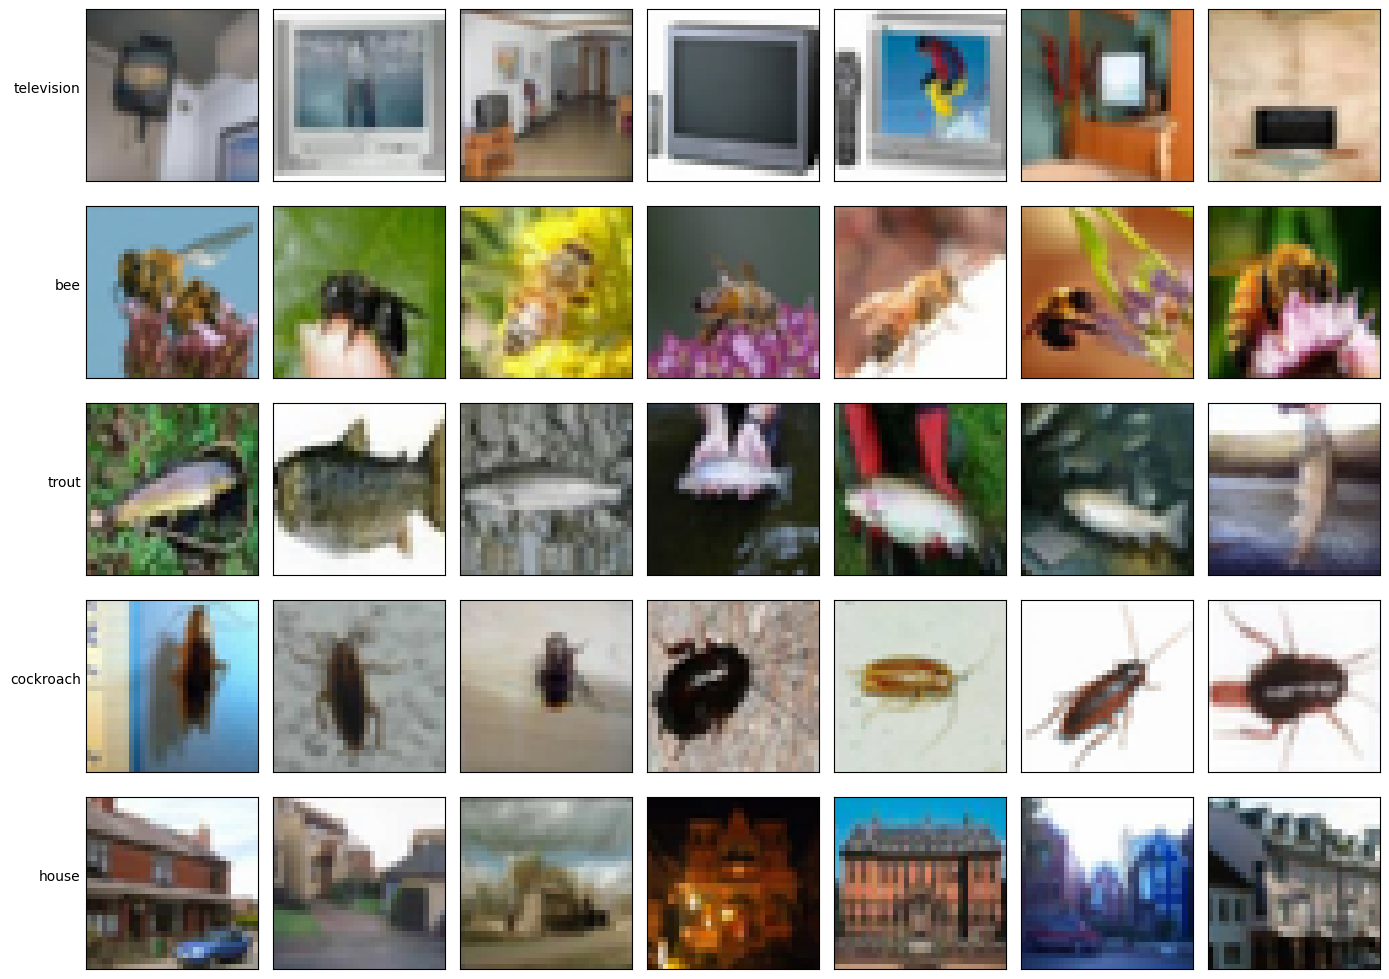

In [19]:
display_classes_examples(val_loader, top_classes_significance["bottom_classes_ids"], 7)